# Phân tích độ trễ hệ thống phục vụ mô hình ngôn ngữ

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
print(sys.executable)
print(sys.version)

c:\Users\Admin\Desktop\Nexus Lab\Measure_latency\.venv\Scripts\python.exe
3.13.13 | packaged by Anaconda, Inc. | (main, Apr 14 2026, 06:12:50) [MSC v.1942 64 bit (AMD64)]


In [2]:
requests = pd.read_csv("data/requests.csv")
tokens = pd.read_csv("data/tokens.csv")

In [3]:
print("requests:", requests.shape)
print("tokens:", tokens.shape)

requests: (12040, 7)
tokens: (1829816, 3)


In [4]:
requests.head()

,request_id,arrival_ts_ms,prompt_tokens,output_tokens,ttft_ms,e2e_ms,status
0,r104110,1424966.4,117,292,22.40,5839.65,ok
1,r107988,1990392.0,1303,144,68.40,3168.04,ok
2,r102359,1079066.3,465,122,21.09,1013.62,ok
3,r103315,1302839.6,203,226,168.45,5383.06,ok
4,r106148,1723195.8,989,263,415.35,6062.83,ok


In [5]:
tokens.head()

,request_id,token_index,itl_ms
0,r100000,1,8.860
1,r100000,2,6.178
2,r100000,3,10.039
3,r100000,4,7.954
4,r100000,5,9.444


In [6]:
requests.info()
tokens.info()

<class 'pandas.DataFrame'>
RangeIndex: 12040 entries, 0 to 12039
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   request_id     12040 non-null  str    
 1   arrival_ts_ms  12040 non-null  float64
 2   prompt_tokens  12040 non-null  int64  
 3   output_tokens  12040 non-null  int64  
 4   ttft_ms        12040 non-null  float64
 5   e2e_ms         12040 non-null  float64
 6   status         12040 non-null  str    
dtypes: float64(3), int64(2), str(2)
memory usage: 658.6 KB
<class 'pandas.DataFrame'>
RangeIndex: 1829816 entries, 0 to 1829815
Data columns (total 3 columns):
 #   Column       Dtype  
---  ------       -----  
 0   request_id   str    
 1   token_index  int64  
 2   itl_ms       float64
dtypes: float64(1), int64(1), str(1)
memory usage: 41.9 MB


## Câu 1 — Tình trạng dữ liệu

### Nhận xét ban đầu

- `requests.csv` có 12.040 dòng và 7 cột.
- `tokens.csv` có 1.829.816 dòng và 3 cột.
- Chưa phát hiện giá trị thiếu qua `info()`.
- Các cột số được pandas nhận diện dưới dạng `int64` hoặc `float64`.
- `status` và `request_id` là dữ liệu dạng chuỗi.

Đây mới chỉ là kiểm tra cấu trúc ban đầu; chưa đủ để kết luận dữ liệu sạch.

In [7]:
#Ô 07 - Kiểm tra tính duy nhất của request_id
n_rows = len(requests)
n_unique_ids = requests["request_id"].nunique()
n_duplicated_rows = requests.duplicated(subset=["request_id"], keep=False).sum()

print("Tổng số dòng:", n_rows)
print("Số request_id khác nhau:", n_unique_ids)
print("Số dòng thuộc request_id xuất hiện nhiều lần:", n_duplicated_rows)

duplicate_requests = (
    requests[
        requests.duplicated(subset=["request_id"], keep=False)
    ]
    .sort_values("request_id")
)

print("\nCác bản ghi có request_id xuất hiện nhiều lần:")
display(duplicate_requests)

Tổng số dòng: 12040
Số request_id khác nhau: 12000
Số dòng thuộc request_id xuất hiện nhiều lần: 80

Các bản ghi có request_id xuất hiện nhiều lần:


,request_id,arrival_ts_ms,prompt_tokens,output_tokens,ttft_ms,e2e_ms,status
10064,r100049,22900.2,317,81,109.32,838.96,ok
3005,r100049,22900.2,317,81,109.32,838.96,ok
7279,r100272,135136.9,481,90,215.38,828.12,ok
8377,r100272,135136.9,481,90,215.38,828.12,ok
9962,r100389,194745.9,310,155,101.29,1437.36,ok
...,...,...,...,...,...,...,...
10348,r111426,3344618.2,155,433,119.86,3175.49,ok
10431,r111631,3436563.9,346,59,160.42,641.69,ok
10904,r111631,3436563.9,346,59,160.42,641.69,ok
11336,r111669,3453019.2,142,34,26.61,351.79,ok


Kiểm tra tính duy nhất của request_id
[đo được] File có 12.040 dòng nhưng chỉ có 12.000 request_id khác nhau [ô 07]. Có 80 dòng thuộc các ID xuất hiện nhiều lần. Như vậy có 40 lần xuất hiện dư so với giả định mỗi ID tương ứng một dòng.

Một số cặp quan sát được có cùng request_id và cùng toàn bộ giá trị ở các cột còn lại, nhưng cần kiểm tra toàn bộ các ID lặp trước khi quyết định cách xử lý.

In [8]:
# [ô 08] Kiểm tra các request_id lặp xuất hiện bao nhiêu lần
# và các dòng có giống hoàn toàn nhau hay không

duplicate_id_counts = (
    duplicate_requests["request_id"]
    .value_counts()
    .sort_values(ascending=False)
)

print("Số request_id bị lặp:", len(duplicate_id_counts))

print("\nPhân bố số lần xuất hiện:")
print(duplicate_id_counts.value_counts().sort_index())

# Kiểm tra số dòng trùng hoàn toàn trên tất cả 7 cột
n_exact_duplicate_rows = requests.duplicated(keep=False).sum()

print("\nSố dòng thuộc nhóm trùng hoàn toàn trên tất cả các cột:",
      n_exact_duplicate_rows)

Số request_id bị lặp: 40

Phân bố số lần xuất hiện:
count
2    40
Name: count, dtype: int64

Số dòng thuộc nhóm trùng hoàn toàn trên tất cả các cột: 80


Kết quả kiểm tra bản ghi lặp

[đo được] Có 40 request_id bị lặp và mỗi ID xuất hiện đúng 2 lần [ô 08]. Cả 80 dòng thuộc các nhóm này đều trùng hoàn toàn trên toàn bộ 7 cột [ô 08].

[suy ra] Theo mô tả dữ liệu rằng mỗi dòng tương ứng với một request, 40 lần xuất hiện thứ hai không cung cấp thêm phép đo độc lập và có thể được xem là các bản sao dư.

[phỏng đoán] Các bản sao này có thể xuất phát từ quá trình ghi log hoặc tạo dữ liệu, nhưng bộ dữ liệu hiện tại không đủ để xác định nguyên nhân.

### Ô 09 — Tạo dữ liệu làm việc sau khi loại bản ghi trùng hoàn toàn

In [9]:
# [ô 09] Tạo dữ liệu làm việc sau khi loại exact duplicate

requests_work = requests.drop_duplicates(keep="first").copy()

print("Số dòng dữ liệu gốc:", len(requests))
print("Số dòng dữ liệu làm việc:", len(requests_work))
print("Số dòng đã loại:", len(requests) - len(requests_work))

print("Số request_id khác nhau:", requests_work["request_id"].nunique())

print(
    "Số request_id còn bị lặp:",
    requests_work["request_id"].duplicated().sum()
)

Số dòng dữ liệu gốc: 12040
Số dòng dữ liệu làm việc: 12000
Số dòng đã loại: 40
Số request_id khác nhau: 12000
Số request_id còn bị lặp: 0


**Xử lý bản ghi trùng**

**[đo được]** Dữ liệu gốc có 12.040 dòng. Có 40 `request_id` xuất hiện hai lần và các cặp tương ứng trùng hoàn toàn trên cả 7 cột [ô 07–08].

**[suy ra]** Vì mỗi dòng được mô tả là một request và các cặp lặp không chứa thêm thông tin khác biệt, em giữ một bản ghi đại diện cho mỗi cặp và tạo `requests_work` để tiếp tục phân tích. Sau bước này còn 12.000 dòng, tương ứng 12.000 `request_id` duy nhất [ô 09].

DataFrame `requests` gốc được giữ nguyên để có thể đối chiếu lại.


In [10]:
# [ô 10] Kiểm tra các giá trị và số lượng của status

status_counts = requests_work["status"].value_counts(dropna=False)

print("Các giá trị status và số lượng:")
print(status_counts)

print("\nSố loại status khác nhau:",
      requests_work["status"].nunique(dropna=False))

Các giá trị status và số lượng:
status
ok           11689
error          175
cancelled      136
Name: count, dtype: int64

Số loại status khác nhau: 3


**Kiểm tra trạng thái kết thúc request**

**[đo được]** Trong 12.000 request sau khi loại bản sao dư, có 11.689 request có `status = ok`, 175 request `error` và 136 request `cancelled` [ô 10]. Như vậy có 311 request không kết thúc với trạng thái `ok`.

Chưa loại các request `error` hoặc `cancelled` ở bước này vì giá trị `status` một mình chưa đủ để xác định các số đo độ trễ của chúng có còn ý nghĩa hay không. Bước tiếp theo là xem trực tiếp các bản ghi thuộc hai nhóm này.


In [11]:
# [ô 11] Xem trực tiếp các request không kết thúc với status = ok

non_ok = requests_work[
    requests_work["status"].isin(["error", "cancelled"])
]

print("Tổng số request không ok:", len(non_ok))

print("\nMột số request status = error:")
display(
    non_ok[non_ok["status"] == "error"].head(10)
)

print("\nMột số request status = cancelled:")
display(
    non_ok[non_ok["status"] == "cancelled"].head(10)
)

Tổng số request không ok: 311

Một số request status = error:


,request_id,arrival_ts_ms,prompt_tokens,output_tokens,ttft_ms,e2e_ms,status
12,r108049,2000805.3,161,0,12185.06,12186.92,error
31,r108469,2063698.3,645,0,10521.58,10527.96,error
86,r100939,441716.3,377,0,9563.03,9566.71,error
133,r105197,1585586.6,234,0,22422.75,22427.93,error
142,r100642,304977.3,1879,0,19787.24,19793.52,error
182,r108202,2022480.2,408,0,17397.16,17406.35,error
325,r109113,2301166.0,147,0,10000.86,10004.40,error
326,r100351,177342.9,134,0,29840.48,29847.07,error
336,r108780,2153887.1,449,0,27034.41,27035.75,error
345,r103684,1356573.5,305,0,12281.83,12285.44,error



Một số request status = cancelled:


,request_id,arrival_ts_ms,prompt_tokens,output_tokens,ttft_ms,e2e_ms,status
34,r104227,1443621.3,563,15,28.59,396.34,cancelled
144,r105731,1662644.7,365,10,54.17,255.71,cancelled
214,r109890,2645212.7,443,36,60.91,319.78,cancelled
233,r102780,1221730.6,1015,22,365.55,839.91,cancelled
259,r110617,2986461.2,417,12,38.03,131.31,cancelled
740,r110142,2766728.3,38,62,119.32,669.39,cancelled
927,r100481,232585.5,211,6,109.24,156.23,cancelled
1011,r105458,1621549.5,402,16,223.90,478.46,cancelled
1106,r108748,2133962.5,579,18,173.98,318.68,cancelled
1144,r102634,1196536.0,159,54,34.38,496.39,cancelled


**Quan sát ban đầu về các request không `ok`**

**[đo được]** Trong 10 bản ghi `error` được xem trực tiếp, tất cả đều có `output_tokens = 0`; trong 10 bản ghi `cancelled` được xem, tất cả đều có `output_tokens > 0` [ô 11].

Đây mới là quan sát trên một số bản ghi mẫu, chưa đủ để kết luận cho toàn bộ hai nhóm. Bước tiếp theo kiểm tra đặc điểm này trên tất cả request `error` và `cancelled`.


### Ô 12 - Kiểm tra output_tokens của toàn bộ error và cancelled

In [12]:
# [ô 12] Kiểm tra output_tokens của toàn bộ error và cancelled

for status_name in ["error", "cancelled"]:
    subset = requests_work[requests_work["status"] == status_name]

    print(f"\nStatus = {status_name}")
    print("Tổng số request:", len(subset))
    print("output_tokens = 0:", (subset["output_tokens"] == 0).sum())
    print("output_tokens > 0:", (subset["output_tokens"] > 0).sum())
    print("output_tokens < 0:", (subset["output_tokens"] < 0).sum())


Status = error
Tổng số request: 175
output_tokens = 0: 175
output_tokens > 0: 0
output_tokens < 0: 0

Status = cancelled
Tổng số request: 136
output_tokens = 0: 0
output_tokens > 0: 136
output_tokens < 0: 0


**Kiểm tra số token đầu ra theo trạng thái**

**[đo được]** Toàn bộ 175 request có `status = error` đều có `output_tokens = 0`, trong khi toàn bộ 136 request `cancelled` đều có `output_tokens > 0` [ô 12].

**[suy ra]** Hai nhóm `error` và `cancelled` có đặc điểm khác nhau và cần được xem xét riêng khi xây dựng tiêu chí request hợp lệ.

**[phỏng đoán]** Request `error` có thể thất bại trước khi sinh token, còn request `cancelled` có thể đã bắt đầu sinh token trước khi bị hủy. Bộ dữ liệu hiện tại chưa cung cấp nguyên nhân kỹ thuật để xác nhận cơ chế này.


In [13]:
# [ô 13] Kiểm tra quan hệ ttft_ms và e2e_ms của request error

error_requests = requests_work[
    requests_work["status"] == "error"
].copy()

error_requests["e2e_minus_ttft_ms"] = (
    error_requests["e2e_ms"] - error_requests["ttft_ms"]
)

print("Số request error:", len(error_requests))

print(
    "Số dòng có ttft_ms > e2e_ms:",
    (error_requests["ttft_ms"] > error_requests["e2e_ms"]).sum()
)

print(
    "Số dòng có ttft_ms <= 0:",
    (error_requests["ttft_ms"] <= 0).sum()
)

print("\ne2e_ms - ttft_ms:")
print(error_requests["e2e_minus_ttft_ms"].describe())

Số request error: 175
Số dòng có ttft_ms > e2e_ms: 0
Số dòng có ttft_ms <= 0: 0

e2e_ms - ttft_ms:
count      175.000000
mean       207.488686
std       1556.745412
min          0.290000
25%          2.095000
50%          3.320000
75%          5.145000
max      13741.080000
Name: e2e_minus_ttft_ms, dtype: float64


**Kiểm tra thời gian của request `error`**

**[đo được]** Cả 175 request `error` đều có `ttft_ms > 0` và không có trường hợp `ttft_ms > e2e_ms` [ô 13]. Chênh lệch `e2e_ms - ttft_ms` có trung vị 3,32 ms và 75% số request có chênh lệch không quá 5,145 ms, nhưng giá trị lớn nhất đạt 13.741,08 ms [ô 13].

**[suy ra]** Với phần lớn request `error`, thời điểm được ghi trong `ttft_ms` nằm rất gần thời điểm request kết thúc. Tuy nhiên, vì các request này đều có `output_tokens = 0` [ô 12], ý nghĩa của `ttft_ms` đối với nhóm `error` chưa rõ theo định nghĩa TTFT là thời gian đến token đầu tiên.

**[phỏng đoán]** Giá trị `ttft_ms` của request lỗi có thể đang phản ánh một mốc lỗi hoặc thời gian chờ khác thay vì thời gian thực sự nhận token đầu tiên. Dữ liệu hiện có chưa đủ để xác nhận cơ chế này.


In [14]:
# [ô 14] Xem các request error có e2e_ms - ttft_ms lớn nhất

error_largest_gap = (
    error_requests
    .sort_values("e2e_minus_ttft_ms", ascending=False)
    [
        [
            "request_id",
            "prompt_tokens",
            "output_tokens",
            "ttft_ms",
            "e2e_ms",
            "e2e_minus_ttft_ms",
            "status"
        ]
    ]
    .head(10)
)

display(error_largest_gap)

,request_id,prompt_tokens,output_tokens,ttft_ms,e2e_ms,e2e_minus_ttft_ms,status
1273,r110103,733,0,22154.12,35895.20,13741.08,error
6228,r108920,142,0,17786.60,28822.24,11035.64,error
4050,r101590,250,0,17561.40,28452.20,10890.80,error
1576,r110904,160,0,11556.70,11569.36,12.66,error
6080,r104416,675,0,29558.95,29569.28,10.33,error
10678,r106469,417,0,11541.52,11551.64,10.12,error
9590,r102710,377,0,9080.71,9090.51,9.80,error
182,r108202,408,0,17397.16,17406.35,9.19,error
9251,r110608,4216,0,17610.27,17619.19,8.92,error
10852,r103401,163,0,21429.73,21438.20,8.47,error


**Đánh giá nhóm `error` đối với phân tích TTFT**

**[đo được]** Ba request `error` có `e2e_ms - ttft_ms` khoảng 10,9–13,7 giây, trong khi request có chênh lệch lớn thứ tư chỉ là 12,66 ms [ô 14]. Điều này cho thấy một số request lỗi có hành vi thời gian khác với phần lớn nhóm `error`.

**[suy ra]** Đối với mục tiêu phân tích TTFT, 175 request `error` không được sử dụng. Tất cả các request này đều có `output_tokens = 0` [ô 12], trong khi TTFT được định nghĩa là thời gian đến token đầu tiên. Vì vậy ý nghĩa của `ttft_ms` ở các request này không đủ rõ để coi là phép đo TTFT hợp lệ.

Các request `error` không được coi là dữ liệu vô ích; chúng chỉ được tách khỏi tập dùng để phân tích TTFT. Nguyên nhân kỹ thuật tạo ra các giá trị thời gian của nhóm lỗi chưa xác định được từ dữ liệu hiện có.


In [15]:
# [ô 15] Kiểm tra tính hợp lý của TTFT đối với request cancelled

cancelled_requests = requests_work[
    requests_work["status"] == "cancelled"
].copy()

print("Số request cancelled:", len(cancelled_requests))

print(
    "Số request có output_tokens <= 0:",
    (cancelled_requests["output_tokens"] <= 0).sum()
)

print(
    "Số request có ttft_ms <= 0:",
    (cancelled_requests["ttft_ms"] <= 0).sum()
)

print(
    "Số request có ttft_ms > e2e_ms:",
    (cancelled_requests["ttft_ms"] > cancelled_requests["e2e_ms"]).sum()
)

Số request cancelled: 136
Số request có output_tokens <= 0: 0
Số request có ttft_ms <= 0: 0
Số request có ttft_ms > e2e_ms: 0


**Đánh giá request `cancelled` đối với TTFT**

**[đo được]** Có 136 request `cancelled`. Tất cả đều có `output_tokens > 0`, `ttft_ms > 0` và không có trường hợp `ttft_ms > e2e_ms` [ô 12, ô 15].

**[suy ra]** Các request `cancelled` vẫn có thể được sử dụng để phân tích TTFT vì dữ liệu cho thấy chúng đã sinh token đầu ra và giá trị TTFT thỏa các quan hệ thời gian cơ bản. Vì vậy em không loại request chỉ dựa trên điều kiện `status != ok`.

Việc `cancelled` xảy ra ở giai đoạn nào của quá trình phục vụ request chưa xác định được từ các cột hiện có.


In [16]:
# [ô 16] Kiểm tra các ràng buộc logic cơ bản của requests_work

checks = {
    "arrival_ts_ms < 0":
        (requests_work["arrival_ts_ms"] < 0).sum(),

    "prompt_tokens <= 0":
        (requests_work["prompt_tokens"] <= 0).sum(),

    "output_tokens < 0":
        (requests_work["output_tokens"] < 0).sum(),

    "ttft_ms <= 0":
        (requests_work["ttft_ms"] <= 0).sum(),

    "e2e_ms <= 0":
        (requests_work["e2e_ms"] <= 0).sum(),

    "ttft_ms > e2e_ms":
        (requests_work["ttft_ms"] > requests_work["e2e_ms"]).sum()
}

for condition, count in checks.items():
    print(f"{condition}: {count}")

arrival_ts_ms < 0: 0
prompt_tokens <= 0: 0
output_tokens < 0: 0
ttft_ms <= 0: 0
e2e_ms <= 0: 0
ttft_ms > e2e_ms: 0


**Kiểm tra các ràng buộc logic cơ bản**

**[đo được]** Trong 12.000 request sau khi xử lý bản ghi trùng, không phát hiện giá trị âm hoặc bằng 0 ở các trường thời gian, không có `prompt_tokens <= 0` hay `output_tokens < 0`, và không có trường hợp `ttft_ms > e2e_ms` [ô 16].

**[suy ra]** Theo các ràng buộc logic đã kiểm tra, các trường số không cho thấy thêm lỗi cấu trúc rõ ràng cần loại bỏ ở bước này.


In [17]:
# [ô 17] Kiểm tra output_tokens = 0 theo từng status

output_zero_by_status = (
    requests_work
    .assign(output_tokens_zero=requests_work["output_tokens"] == 0)
    .groupby(["status", "output_tokens_zero"])
    .size()
    .unstack(fill_value=0)
)

display(output_zero_by_status)

output_tokens_zero,False,True
status,,
cancelled,136,0
error,0,175
ok,11689,0


**Đối chiếu trạng thái với số token đầu ra**

**[đo được]** Tất cả 11.689 request `ok` và 136 request `cancelled` đều có `output_tokens > 0`, trong khi toàn bộ 175 request `error` có `output_tokens = 0` [ô 17].

**[suy ra]** Trong bộ dữ liệu này, việc có token đầu ra phân tách chính xác nhóm `ok` và `cancelled` khỏi nhóm `error`. Vì TTFT được định nghĩa là thời gian đến token đầu tiên, `output_tokens > 0` là bằng chứng trực tiếp hơn để đánh giá khả năng sử dụng TTFT so với việc chỉ kiểm tra `status == "ok"`.

Kết quả này chỉ áp dụng cho bộ dữ liệu đang phân tích, không được coi là quy luật chung của mọi hệ thống phục vụ mô hình.


In [18]:
# [ô 18] Xây dựng tiêu chí request hợp lệ cho phân tích TTFT

valid_ttft_mask = (
    (requests_work["output_tokens"] > 0)
    & (requests_work["ttft_ms"] > 0)
    & (requests_work["e2e_ms"] > 0)
    & (requests_work["ttft_ms"] <= requests_work["e2e_ms"])
    & (requests_work["prompt_tokens"] > 0)
    & (requests_work["arrival_ts_ms"] >= 0)
)

requests_ttft = requests_work[valid_ttft_mask].copy()
excluded_ttft = requests_work[~valid_ttft_mask].copy()

print("Tổng số request sau khi xử lý duplicate:", len(requests_work))
print("Số request dùng được cho phân tích TTFT:", len(requests_ttft))
print("Số request không dùng cho phân tích TTFT:", len(excluded_ttft))

print("\nStatus của các request dùng được:")
print(requests_ttft["status"].value_counts())

print("\nStatus của các request không dùng:")
print(excluded_ttft["status"].value_counts())

Tổng số request sau khi xử lý duplicate: 12000
Số request dùng được cho phân tích TTFT: 11825
Số request không dùng cho phân tích TTFT: 175

Status của các request dùng được:
status
ok           11689
cancelled      136
Name: count, dtype: int64

Status của các request không dùng:
status
error    175
Name: count, dtype: int64


In [19]:
# [ô 19] Đối soát kết quả audit requests.csv

print("=== Đối soát số lượng ===")
print("Dữ liệu gốc:", len(requests))
print("Bản sao dư đã loại:", len(requests) - len(requests_work))
print("Request duy nhất sau duplicate:", len(requests_work))
print("Không dùng cho TTFT:", len(excluded_ttft))
print("Dùng cho TTFT:", len(requests_ttft))

print("\n=== Kiểm tra tập TTFT cuối cùng ===")
print(
    "request_id còn bị lặp:",
    requests_ttft["request_id"].duplicated().sum()
)

print(
    "output_tokens <= 0:",
    (requests_ttft["output_tokens"] <= 0).sum()
)

print(
    "ttft_ms <= 0:",
    (requests_ttft["ttft_ms"] <= 0).sum()
)

print(
    "ttft_ms > e2e_ms:",
    (requests_ttft["ttft_ms"] > requests_ttft["e2e_ms"]).sum()
)

print(
    "prompt_tokens <= 0:",
    (requests_ttft["prompt_tokens"] <= 0).sum()
)

print(
    "arrival_ts_ms < 0:",
    (requests_ttft["arrival_ts_ms"] < 0).sum()
)

=== Đối soát số lượng ===
Dữ liệu gốc: 12040
Bản sao dư đã loại: 40
Request duy nhất sau duplicate: 12000
Không dùng cho TTFT: 175
Dùng cho TTFT: 11825

=== Kiểm tra tập TTFT cuối cùng ===
request_id còn bị lặp: 0
output_tokens <= 0: 0
ttft_ms <= 0: 0
ttft_ms > e2e_ms: 0
prompt_tokens <= 0: 0
arrival_ts_ms < 0: 0


Kết luận audit requests.csv

[đo được] Dữ liệu gốc gồm 12.040 dòng. Có 40 request_id xuất hiện hai lần và các cặp tương ứng trùng hoàn toàn trên cả 7 cột [ô 07–08]. Sau khi giữ một bản ghi đại diện cho mỗi cặp, còn 12.000 request duy nhất [ô 09].

[đo được] Trong 12.000 request này có 11.689 ok, 136 cancelled và 175 error [ô 10]. Tất cả request error đều có output_tokens = 0, trong khi tất cả request ok và cancelled đều có output_tokens > 0 [ô 17].

[suy ra] Đối với phân tích TTFT, request cần có bằng chứng rằng token đầu tiên đã tồn tại. Vì vậy 175 request error không được đưa vào tập phân tích TTFT. Các request cancelled vẫn được giữ vì chúng có token đầu ra, TTFT dương và TTFT không vượt E2E [ô 12, ô 15].

[đo được] Tập dữ liệu cuối dùng cho phân tích TTFT gồm 11.825 request: 11.689 ok và 136 cancelled [ô 18]. Tập này không còn request_id lặp, không có output_tokens <= 0, ttft_ms <= 0, ttft_ms > e2e_ms, prompt_tokens <= 0 hoặc arrival_ts_ms < 0 [ô 19].

[phỏng đoán] Nguyên nhân kỹ thuật của các request lỗi, bản ghi lặp và một số hành vi thời gian đặc biệt trong nhóm error chưa thể xác định từ các cột hiện có.

## Câu 2 — Phân phối TTFT


In [20]:
# [ô 20] Khảo sát thang đo, trung tâm, độ phân tán
# và phía giá trị lớn của TTFT

ttft = requests_ttft["ttft_ms"]

q05 = ttft.quantile(0.05)
q25 = ttft.quantile(0.25)
q50 = ttft.quantile(0.50)
q75 = ttft.quantile(0.75)
q95 = ttft.quantile(0.95)

ttft_overview = pd.Series({
    "n": len(ttft),
    "min_ms": ttft.min(),
    "q05_ms": q05,
    "q25_ms": q25,
    "median_ms": q50,
    "q75_ms": q75,
    "q95_ms": q95,
    "max_ms": ttft.max(),
    "IQR_ms": q75 - q25,
    "q95_div_median": q95 / q50,
    "max_div_median": ttft.max() / q50
})

display(ttft_overview.to_frame("value"))

,value
n,11825.000000
min_ms,10.730000
q05_ms,24.754000
q25_ms,48.380000
median_ms,130.900000
q75_ms,210.980000
q95_ms,433.150000
max_ms,2036.460000
IQR_ms,162.600000
q95_div_median,3.309015


### Nhận xét Ô 20

- **[đo được]** Tập phân tích TTFT gồm 11.825 request.
- **[đo được]** Median TTFT là 130,90 ms. 50% dữ liệu ở giữa nằm từ 48,38 ms (Q25) đến 210,98 ms (Q75), tương ứng IQR = 162,60 ms.
- **[đo được]** Trong vùng trung tâm, khoảng cách Q25 → median (82,52 ms) và median → Q75 (80,08 ms) khá gần nhau.
- **[đo được]** Q95 là 433,15 ms, gấp khoảng 3,31 lần median; giá trị lớn nhất là 2036,46 ms, gấp khoảng 15,56 lần median.
- **[suy ra]** Phía TTFT lớn kéo dài đáng kể hơn phía thấp, vì vậy cần quan sát hình dạng phân phối và kiểm tra cấu trúc ở phía giá trị lớn.
- **[phỏng đoán]** Chưa đề xuất cơ chế kỹ thuật ở bước này.

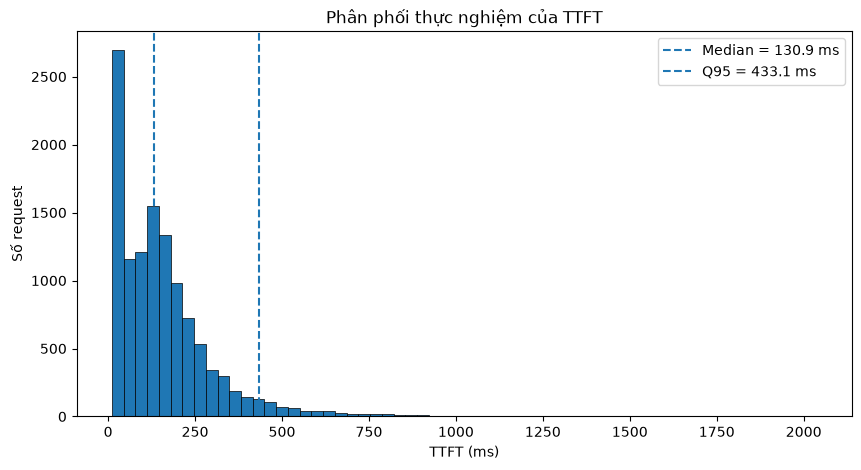

In [21]:
# [ô 21] Histogram toàn bộ phân phối TTFT

plt.figure(figsize=(10, 5))

plt.hist(
    requests_ttft["ttft_ms"],
    bins=60,
    edgecolor="black",
    linewidth=0.5
)

plt.axvline(
    q50,
    linestyle="--",
    label=f"Median = {q50:.1f} ms"
)

plt.axvline(
    q95,
    linestyle="--",
    label=f"Q95 = {q95:.1f} ms"
)

plt.xlabel("TTFT (ms)")
plt.ylabel("Số request")
plt.title("Phân phối thực nghiệm của TTFT")
plt.legend()

plt.show()

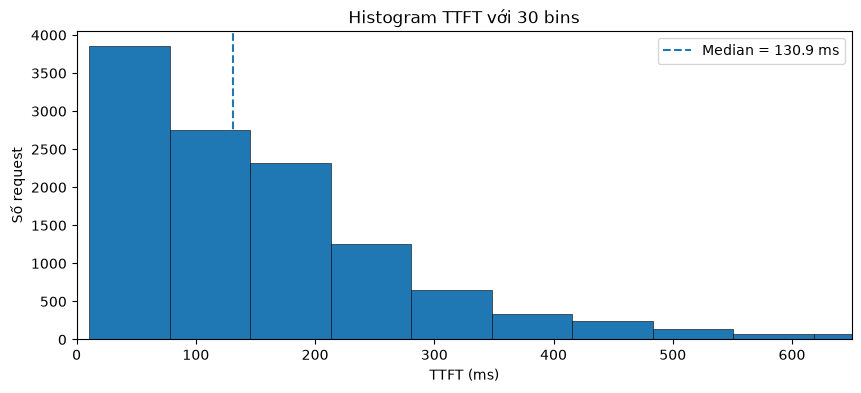

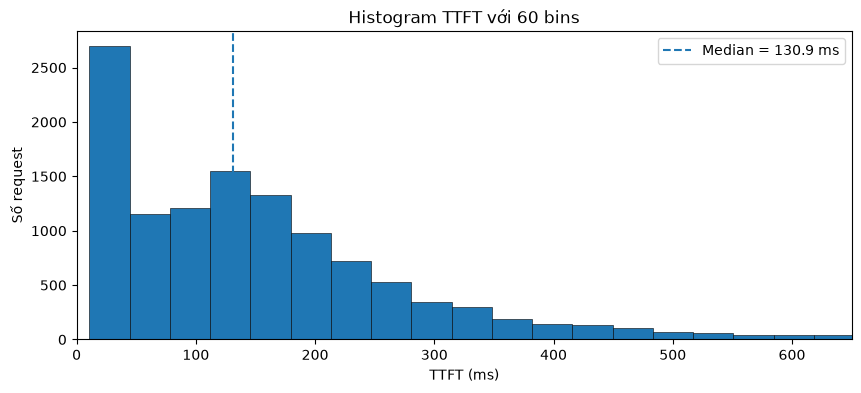

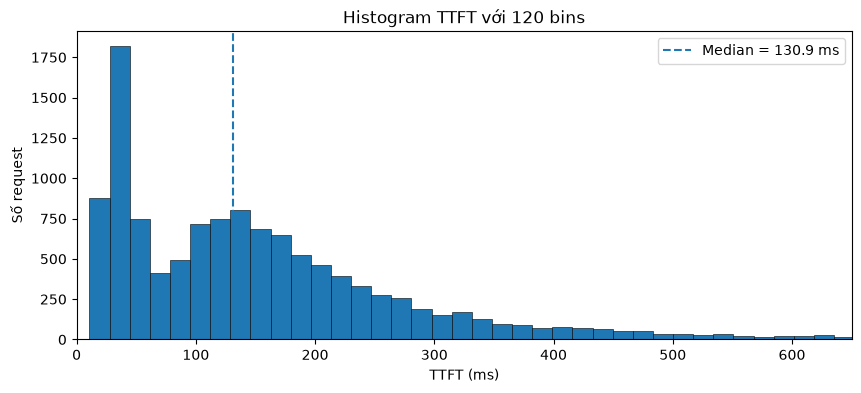

In [22]:
# [ô 22] Kiểm tra độ ổn định của hình dạng TTFT
# khi thay đổi số lượng bin

for n_bins in [30, 60, 120]:

    plt.figure(figsize=(10, 4))

    plt.hist(
        ttft,
        bins=n_bins,
        edgecolor="black",
        linewidth=0.4
    )

    plt.axvline(
        q50,
        linestyle="--",
        label=f"Median = {q50:.1f} ms"
    )

    plt.xlabel("TTFT (ms)")
    plt.ylabel("Số request")
    plt.title(f"Histogram TTFT với {n_bins} bins")

    # Chỉ zoom phần chính của phân phối để nhìn cấu trúc rõ hơn.
    # Dữ liệu > 650 ms KHÔNG bị xóa.
    plt.xlim(0, 650)

    plt.legend()
    plt.show()

### Nhận xét Ô 22

- **[đo được]** Khi thay đổi histogram từ 30 sang 60 và 120 bins, phân phối TTFT vẫn có dạng lệch phải.
- **[đo được]** Với 60 và 120 bins, xuất hiện một vùng tập trung rất mạnh ở TTFT thấp, sau đó tần suất giảm rồi tăng trở lại thành một vùng tập trung rộng hơn khoảng 100–180 ms.
- **[đo được]** Với 30 bins, cấu trúc này bị làm mượt do mỗi bin rộng hơn.
- **[suy ra]** Cấu trúc quan sát được không hoàn toàn chỉ do một lựa chọn `bins=60`, nhưng cần định lượng số request trong các khoảng TTFT trước khi kết luận có nhiều mode.
- **[phỏng đoán]** Chưa xác định cơ chế kỹ thuật sinh ra cấu trúc này.

In [23]:
# [ô 23] Đếm request theo các khoảng TTFT cố định 20 ms
# để định lượng cấu trúc quan sát thấy trên histogram

bin_edges = np.arange(0, 321, 20)

ttft_bins_20ms = pd.cut(
    ttft,
    bins=bin_edges,
    right=False
)

bin_counts = (
    ttft_bins_20ms
    .value_counts(sort=False)
    .rename("count")
    .to_frame()
)

bin_counts["percent_all"] = (
    bin_counts["count"] / len(ttft) * 100
)

display(bin_counts)

,count,percent_all
ttft_ms,,
"[0, 20)",210,1.775899
"[20, 40)",2108,17.826638
"[40, 60)",1083,9.158562
"[60, 80)",486,4.109937
"[80, 100)",648,5.479915
"[100, 120)",877,7.416490
"[120, 140)",929,7.856237
"[140, 160)",851,7.196617
"[160, 180)",764,6.460888


### Nhận xét Ô 23

- **[đo được]** Khi chia TTFT thành các khoảng cố định 20 ms, khoảng [20, 40) có 2.108 request (17,83%), là khoảng có số request lớn nhất.
- **[đo được]** Sau đỉnh này, số request giảm còn 486 ở khoảng [60, 80), sau đó tăng trở lại: 648 ở [80, 100), 877 ở [100, 120) và 929 ở [120, 140).
- **[đo được]** Nhóm TTFT < 60 ms gồm 3.401 request (28,76%); vùng [60, 80) gồm 486 request (4,11%); vùng [80, 180) gồm 4.069 request (34,41%).
- **[suy ra]** Mẫu đỉnh thấp → vùng trũng → vùng tập trung thứ hai vẫn xuất hiện khi dùng các khoảng TTFT cố định, nên cấu trúc này không chỉ phụ thuộc vào một cách chia bin của histogram.
- **[phỏng đoán]** Chưa xác định cơ chế kỹ thuật tạo ra hai vùng tập trung.

In [24]:
# [ô 24] Xem trực tiếp một số request ở ba vùng TTFT

cols_to_view = [
    "request_id",
    "arrival_ts_ms",
    "prompt_tokens",
    "output_tokens",
    "ttft_ms",
    "e2e_ms",
    "status"
]

region_low = requests_ttft[
    requests_ttft["ttft_ms"] < 60
]

region_valley = requests_ttft[
    (requests_ttft["ttft_ms"] >= 60) &
    (requests_ttft["ttft_ms"] < 80)
]

region_second = requests_ttft[
    (requests_ttft["ttft_ms"] >= 80) &
    (requests_ttft["ttft_ms"] < 180)
]

print("=== VÙNG TTFT < 60 ms ===")
display(region_low[cols_to_view].head(10))

print("=== VÙNG TRŨNG 60–80 ms ===")
display(region_valley[cols_to_view].head(10))

print("=== VÙNG TTFT 80–180 ms ===")
display(region_second[cols_to_view].head(10))

=== VÙNG TTFT < 60 ms ===


,request_id,arrival_ts_ms,prompt_tokens,output_tokens,ttft_ms,e2e_ms,status
0,r104110,1424966.4,117,292,22.40,5839.65,ok
2,r102359,1079066.3,465,122,21.09,1013.62,ok
5,r100754,354185.1,1435,68,39.70,584.78,ok
9,r103637,1346210.4,394,357,32.11,8688.00,ok
11,r108781,2155176.3,559,56,39.76,482.02,ok
14,r106351,1751613.0,79,73,22.94,1728.82,ok
15,r110989,3165837.5,799,129,24.34,1070.18,ok
19,r105858,1680732.4,235,40,43.55,978.71,ok
22,r105498,1628416.3,360,31,46.44,692.13,ok
23,r105658,1652311.8,393,57,59.78,1314.14,ok


=== VÙNG TRŨNG 60–80 ms ===


,request_id,arrival_ts_ms,prompt_tokens,output_tokens,ttft_ms,e2e_ms,status
1,r107988,1990392.0,1303,144,68.40,3168.04,ok
10,r104989,1553542.2,725,118,70.41,2785.50,ok
47,r105262,1595322.8,110,51,64.46,1337.31,ok
58,r104678,1509187.6,194,49,71.01,1173.80,ok
75,r103832,1380691.7,20,289,63.24,6072.23,ok
80,r105085,1567449.3,91,66,64.65,1396.47,ok
96,r104246,1446508.4,132,127,71.63,3120.76,ok
116,r103703,1358699.8,151,278,67.03,5535.12,ok
126,r107649,1939695.8,316,60,64.75,1419.25,ok
132,r101780,800736.6,577,351,75.33,2993.33,ok


=== VÙNG TTFT 80–180 ms ===


,request_id,arrival_ts_ms,prompt_tokens,output_tokens,ttft_ms,e2e_ms,status
3,r103315,1302839.6,203,226,168.45,5383.06,ok
6,r110369,2871897.4,256,355,97.93,2861.51,ok
13,r106905,1831805.6,418,151,120.88,3430.82,ok
17,r111714,3471456.8,273,106,147.15,1185.47,ok
18,r102504,1138138.8,226,254,128.56,2754.84,ok
21,r107056,1855383.3,917,128,171.58,2983.35,ok
32,r108684,2102205.1,267,72,92.02,667.67,ok
35,r110834,3091168.2,300,35,124.25,389.27,ok
37,r102111,951344.9,213,33,98.79,382.16,ok
41,r101184,544915.8,87,434,121.94,3985.45,ok


In [25]:
# [ô 25] So sánh độ dài prompt giữa ba vùng TTFT

prompt_summary = pd.DataFrame({
    "TTFT < 60 ms": {
        "count": len(region_low),
        "q25_prompt": region_low["prompt_tokens"].quantile(0.25),
        "median_prompt": region_low["prompt_tokens"].median(),
        "q75_prompt": region_low["prompt_tokens"].quantile(0.75),
    },

    "TTFT 60–80 ms": {
        "count": len(region_valley),
        "q25_prompt": region_valley["prompt_tokens"].quantile(0.25),
        "median_prompt": region_valley["prompt_tokens"].median(),
        "q75_prompt": region_valley["prompt_tokens"].quantile(0.75),
    },

    "TTFT 80–180 ms": {
        "count": len(region_second),
        "q25_prompt": region_second["prompt_tokens"].quantile(0.25),
        "median_prompt": region_second["prompt_tokens"].median(),
        "q75_prompt": region_second["prompt_tokens"].quantile(0.75),
    }
}).T

prompt_summary["IQR_prompt"] = (
    prompt_summary["q75_prompt"]
    - prompt_summary["q25_prompt"]
)

display(prompt_summary)

,count,q25_prompt,median_prompt,q75_prompt,IQR_prompt
TTFT < 60 ms,3401.0,220.00,383.0,699.0,479.00
TTFT 60–80 ms,486.0,118.25,186.5,342.0,223.75
TTFT 80–180 ms,4069.0,174.00,263.0,389.0,215.00


### Nhận xét Ô 25

- **[đo được]** Nhóm TTFT < 60 ms có median `prompt_tokens` = 383, cao hơn nhóm 60–80 ms (186,5) và nhóm 80–180 ms (263).
- **[đo được]** Khoảng Q25–Q75 của `prompt_tokens` ở nhóm TTFT < 60 ms là 220–699 tokens (IQR = 479), rộng hơn hai nhóm còn lại.
- **[suy ra]** Cấu trúc nhiều vùng của TTFT không được giải thích tốt bởi một quan hệ đơn giản kiểu “prompt ngắn → TTFT thấp, prompt dài → TTFT cao”.
- **[phỏng đoán]** Có thể tồn tại một yếu tố hệ thống khác chi phối TTFT mạnh hơn hoặc tương tác với độ dài prompt; hiện chưa xác định được yếu tố đó.

In [26]:
# [ô 26] Kiểm tra sự xuất hiện theo thời gian
# của hai vùng TTFT chính

requests_ttft = requests_ttft.copy()

requests_ttft["time_5min"] = (
    requests_ttft["arrival_ts_ms"] // 300000
).astype(int)

time_region = pd.crosstab(
    requests_ttft["time_5min"],
    pd.cut(
        requests_ttft["ttft_ms"],
        bins=[0, 60, 80, 180, np.inf],
        labels=[
            "< 60 ms",
            "60–80 ms",
            "80–180 ms",
            ">= 180 ms"
        ],
        right=False
    )
)

time_region.index = [
    f"{i*5:02d}–{(i+1)*5:02d} phút"
    for i in time_region.index
]

display(time_region)

ttft_ms,< 60 ms,60–80 ms,80–180 ms,>= 180 ms
00–05 phút,159,27,227,206
05–10 phút,202,24,249,203
10–15 phút,169,31,224,242
15–20 phút,186,26,223,199
20–25 phút,587,79,637,653
25–30 phút,581,93,698,653
30–35 phút,549,73,698,660
35–40 phút,185,23,235,214
40–45 phút,202,30,220,201
45–50 phút,190,26,188,216


In [27]:
# [ô 27] So sánh tỷ lệ các vùng TTFT trong từng khoảng 5 phút

time_region_percent = (
    time_region
    .div(time_region.sum(axis=1), axis=0)
    * 100
)

time_region_percent["Tổng request"] = time_region.sum(axis=1)

display(time_region_percent.round(2))

ttft_ms,< 60 ms,60–80 ms,80–180 ms,>= 180 ms,Tổng request
00–05 phút,25.69,4.36,36.67,33.28,619
05–10 phút,29.79,3.54,36.73,29.94,678
10–15 phút,25.38,4.65,33.63,36.34,666
15–20 phút,29.34,4.10,35.17,31.39,634
20–25 phút,30.01,4.04,32.57,33.38,1956
25–30 phút,28.69,4.59,34.47,32.25,2025
30–35 phút,27.73,3.69,35.25,33.33,1980
35–40 phút,28.16,3.50,35.77,32.57,657
40–45 phút,30.93,4.59,33.69,30.78,653
45–50 phút,30.65,4.19,30.32,34.84,620


### Nhận xét Ô 27

- **[đo được]** Trong khoảng 20–35 phút, tổng request tăng mạnh lên khoảng 1.956–2.025 request mỗi cửa sổ 5 phút, trong khi phần lớn các cửa sổ khác có khoảng 620–680 request.
- **[đo được]** Mặc dù lưu lượng thay đổi mạnh, tỷ lệ request thuộc các vùng TTFT `<60 ms`, `60–80 ms`, `80–180 ms` và `>=180 ms` nhìn chung vẫn tương đối ổn định giữa các cửa sổ 5 phút.
- **[suy ra]** Cấu trúc nhiều vùng của TTFT khó được giải thích chỉ bằng việc các vùng TTFT xuất hiện ở những giai đoạn thời gian khác nhau trong cửa sổ đo.
- **[suy ra]** Hai vùng TTFT chính có vẻ cùng tồn tại xuyên suốt thời gian đo, kể cả trong giai đoạn lưu lượng tăng mạnh.
- **[phỏng đoán]** Có thể cấu trúc TTFT liên quan đến cơ chế xử lý khác nhau giữa các request thay vì chỉ do một thay đổi trạng thái theo thời gian; dữ liệu hiện tại chưa xác định được cơ chế đó.

In [28]:
# [ô 28] So sánh thành phần TTFT:
# giai đoạn traffic cao 20–35 phút và phần thời gian còn lại

high_traffic = requests_ttft[
    (requests_ttft["arrival_ts_ms"] >= 20 * 60 * 1000) &
    (requests_ttft["arrival_ts_ms"] < 35 * 60 * 1000)
]

normal_traffic = requests_ttft[
    ~(
        (requests_ttft["arrival_ts_ms"] >= 20 * 60 * 1000) &
        (requests_ttft["arrival_ts_ms"] < 35 * 60 * 1000)
    )
]

def ttft_region_percent(df):
    regions = pd.cut(
        df["ttft_ms"],
        bins=[0, 60, 80, 180, np.inf],
        labels=["< 60 ms", "60–80 ms", "80–180 ms", ">= 180 ms"],
        right=False
    )

    counts = regions.value_counts(sort=False)

    return counts / len(df) * 100

traffic_compare = pd.DataFrame({
    "20–35 phút (traffic cao)": ttft_region_percent(high_traffic),
    "Ngoài 20–35 phút": ttft_region_percent(normal_traffic)
}).T

traffic_compare["Tổng request"] = [
    len(high_traffic),
    len(normal_traffic)
]

display(traffic_compare.round(2))

ttft_ms,< 60 ms,60–80 ms,80–180 ms,>= 180 ms,Tổng request
20–35 phút (traffic cao),28.80,4.11,34.11,32.98,5961
Ngoài 20–35 phút,28.72,4.11,34.72,32.45,5864


### Nhận xét Ô 28

- **[đo được]** Khoảng 20–35 phút chứa 5.961/11.825 request TTFT, mặc dù chỉ chiếm 15 phút trong cửa sổ đo, xác nhận đây là giai đoạn lưu lượng cao.
- **[đo được]** Thành phần TTFT trong giai đoạn 20–35 phút gần giống phần thời gian còn lại: `<60 ms` là 28,80% so với 28,72%; `60–80 ms` đều là 4,11%; `80–180 ms` là 34,11% so với 34,72%; `>=180 ms` là 32,98% so với 32,45%.
- **[suy ra]** Đợt tăng lưu lượng 20–35 phút không đi kèm thay đổi lớn về tỷ trọng các vùng TTFT.
- **[suy ra]** Cấu trúc nhiều vùng của TTFT khó được giải thích chỉ bằng việc hệ thống chuyển giữa các trạng thái vận hành ở các giai đoạn thời gian khác nhau.
- **[phỏng đoán]** Có thể cấu trúc này liên quan đến một đặc điểm hoặc cơ chế xử lý ở cấp request; chưa xác định được cơ chế cụ thể.

In [29]:
# [ô 29] Kiểm tra status trong các vùng TTFT

ttft_region = pd.cut(
    requests_ttft["ttft_ms"],
    bins=[0, 60, 80, 180, np.inf],
    labels=[
        "< 60 ms",
        "60–80 ms",
        "80–180 ms",
        ">= 180 ms"
    ],
    right=False
)

status_by_region = pd.crosstab(
    ttft_region,
    requests_ttft["status"]
)

status_by_region["Tổng"] = status_by_region.sum(axis=1)

status_by_region["cancelled_percent"] = (
    status_by_region.get("cancelled", 0)
    / status_by_region["Tổng"]
    * 100
)

display(status_by_region)

status,cancelled,ok,Tổng,cancelled_percent
ttft_ms,,,,
< 60 ms,44,3357,3401,1.293737
60–80 ms,6,480,486,1.234568
80–180 ms,48,4021,4069,1.179651
>= 180 ms,38,3831,3869,0.982166


### Nhận xét Ô 29

- **[đo được]** Tỷ lệ request `cancelled` trong bốn vùng TTFT đều thấp, từ 0,98% đến 1,29%.
- **[đo được]** Vùng TTFT < 60 ms có 44/3.401 request cancelled (1,29%), trong khi vùng 80–180 ms có 48/4.069 request cancelled (1,18%).
- **[suy ra]** Request `cancelled` không chi phối bất kỳ vùng TTFT nào và khó giải thích cấu trúc nhiều vùng quan sát được.
- **[phỏng đoán]** Cấu trúc TTFT có thể liên quan đến một cơ chế xử lý khác chưa được biểu diễn trực tiếp bằng cột `status`.

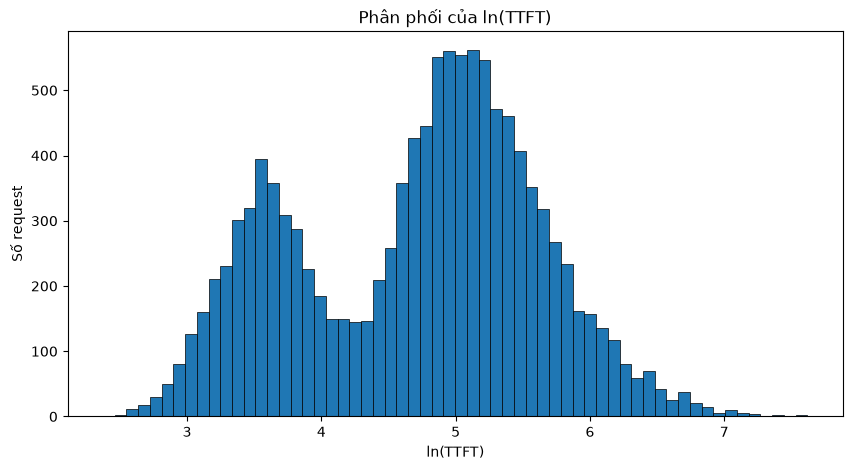

In [30]:
# [ô 30] Kiểm tra hình dạng TTFT sau phép biến đổi log

log_ttft = np.log(ttft)

plt.figure(figsize=(10, 5))

plt.hist(
    log_ttft,
    bins=60,
    edgecolor="black",
    linewidth=0.5
)

plt.xlabel("ln(TTFT)")
plt.ylabel("Số request")
plt.title("Phân phối của ln(TTFT)")

plt.show()

### Nhận xét Ô 30

- **[đo được]** Sau khi biến đổi `ln(TTFT)`, histogram không trở thành một phân phối một đỉnh gần hình chuông mà vẫn xuất hiện hai vùng tập trung rõ rệt.
- **[đo được]** Vùng thứ nhất nằm xấp xỉ quanh `ln(TTFT) ≈ 3,5–3,7`, tương ứng TTFT khoảng 33–40 ms; vùng thứ hai nằm quanh `ln(TTFT) ≈ 4,9–5,2`, tương ứng khoảng 134–181 ms. Giữa hai vùng có một vùng trũng gần khoảng 60–80 ms ở thang TTFT gốc.
- **[suy ra]** Một phân phối lognormal duy nhất khó mô tả tốt toàn bộ TTFT, vì nếu TTFT tuân theo một lognormal đơn giản thì `ln(TTFT)` được kỳ vọng có cấu trúc gần một phân phối normal một đỉnh.
- **[suy ra]** Kết hợp với các kiểm tra ở Ô 21–23, dữ liệu có bằng chứng khá rõ về cấu trúc bimodal.
- **[phỏng đoán]** Hai mode có thể phản ánh hai cơ chế xử lý request khác nhau, nhưng hiện chưa xác định được cơ chế cụ thể.

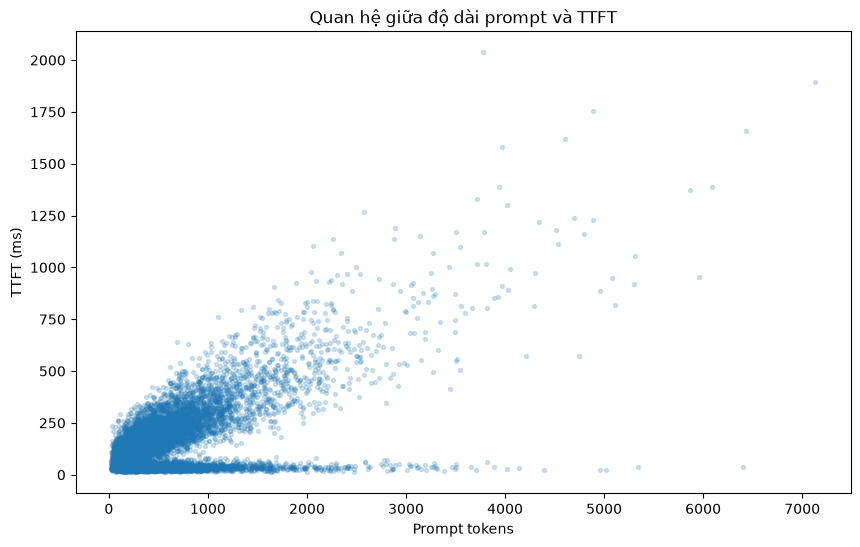

In [31]:
# [ô 31] Quan sát quan hệ giữa prompt_tokens và TTFT

plt.figure(figsize=(10, 6))

plt.scatter(
    requests_ttft["prompt_tokens"],
    requests_ttft["ttft_ms"],
    s=8,
    alpha=0.20
)

plt.xlabel("Prompt tokens")
plt.ylabel("TTFT (ms)")
plt.title("Quan hệ giữa độ dài prompt và TTFT")

plt.show()

### Nhận xét Ô 31

- **[đo được]** Scatter plot giữa `prompt_tokens` và `ttft_ms` cho thấy hai dạng quan hệ khác nhau. Một dải request có TTFT thấp, chủ yếu dưới khoảng 60 ms, xuất hiện trên một khoảng rộng của `prompt_tokens`.
- **[đo được]** Ngoài dải TTFT thấp, tồn tại một đám điểm có xu hướng TTFT tăng khi độ dài prompt tăng.
- **[suy ra]** Cấu trúc bimodal của TTFT có thể liên quan đến hai chế độ xử lý request khác nhau, chứ không chỉ là một phân phối một mode bị lệch phải.
- **[suy ra]** Quan hệ giữa `prompt_tokens` và TTFT không nên được mô tả bằng một quan hệ duy nhất trên toàn bộ dữ liệu trước khi xem xét hai chế độ này riêng biệt.
- **[phỏng đoán]** Một cơ chế như prefix/KV-cache reuse có thể tạo ra dải TTFT thấp ít phụ thuộc vào độ dài prompt, trong khi request không tái sử dụng được trạng thái tính toán có thể phải thực hiện nhiều prefill hơn và có TTFT tăng theo độ dài prompt. Dữ liệu hiện có không chứa thông tin cache nên chưa thể xác minh giả thuyết này.

In [32]:
# [ô 32] Định lượng quan hệ prompt_tokens – TTFT
# trong hai vùng cấu trúc chính

low_mode = requests_ttft[
    requests_ttft["ttft_ms"] < 60
]

upper_branch = requests_ttft[
    requests_ttft["ttft_ms"] >= 80
]

relation_summary = pd.DataFrame({
    "TTFT < 60 ms": {
        "n": len(low_mode),
        "prompt_ttft_corr": low_mode[
            ["prompt_tokens", "ttft_ms"]
        ].corr().iloc[0, 1]
    },

    "TTFT >= 80 ms": {
        "n": len(upper_branch),
        "prompt_ttft_corr": upper_branch[
            ["prompt_tokens", "ttft_ms"]
        ].corr().iloc[0, 1]
    },

    "Toàn bộ TTFT": {
        "n": len(requests_ttft),
        "prompt_ttft_corr": requests_ttft[
            ["prompt_tokens", "ttft_ms"]
        ].corr().iloc[0, 1]
    }
}).T

display(relation_summary)

,n,prompt_ttft_corr
TTFT < 60 ms,3401.0,-0.024297
TTFT >= 80 ms,7938.0,0.857582
Toàn bộ TTFT,11825.0,0.609729


### Nhận xét Ô 32

- **[đo được]** Trong vùng TTFT < 60 ms (3.401 request), Pearson correlation giữa `prompt_tokens` và `ttft_ms` là -0,024, gần 0.
- **[đo được]** Trong vùng TTFT >= 80 ms (7.938 request), correlation là 0,858, cho thấy quan hệ tuyến tính dương mạnh hơn rõ rệt.
- **[đo được]** Nếu tính trên toàn bộ 11.825 request, correlation chỉ còn 0,610.
- **[suy ra]** Hai vùng TTFT có quan hệ với độ dài prompt rất khác nhau: mode thấp gần như không phụ thuộc tuyến tính vào prompt length, trong khi nhánh TTFT phía trên tăng rõ theo prompt length.
- **[suy ra]** Một correlation duy nhất trên toàn bộ dữ liệu che khuất cấu trúc bên trong của TTFT.
- **[phỏng đoán]** Hai quan hệ khác nhau này có thể phản ánh hai chế độ xử lý request, ví dụ một nhóm có khả năng tái sử dụng tính toán của prompt và một nhóm phải thực hiện nhiều prefill hơn. Dữ liệu hiện tại chưa cho phép xác minh cơ chế cụ thể.

In [33]:
# [ô 33] Ước lượng quan hệ tuyến tính giữa prompt length và TTFT
# trong hai vùng cấu trúc chính

low_slope, low_intercept = np.polyfit(
    low_mode["prompt_tokens"],
    low_mode["ttft_ms"],
    1
)

upper_slope, upper_intercept = np.polyfit(
    upper_branch["prompt_tokens"],
    upper_branch["ttft_ms"],
    1
)

linear_params = pd.DataFrame({
    "TTFT < 60 ms": {
        "slope_ms_per_token": low_slope,
        "slope_ms_per_100_tokens": low_slope * 100,
        "intercept_ms": low_intercept
    },

    "TTFT >= 80 ms": {
        "slope_ms_per_token": upper_slope,
        "slope_ms_per_100_tokens": upper_slope * 100,
        "intercept_ms": upper_intercept
    }
}).T

display(linear_params)

,slope_ms_per_token,slope_ms_per_100_tokens,intercept_ms
TTFT < 60 ms,-0.000463,-0.046264,35.592516
TTFT >= 80 ms,0.223847,22.384717,89.500255


### Nhận xét Ô 33

- **[đo được]** Trong mode TTFT < 60 ms, đường hồi quy có slope khoảng -0,000463 ms/token, tương đương -0,046 ms trên 100 prompt token; độ dốc gần 0.
- **[đo được]** Trong nhánh TTFT >= 80 ms, slope là khoảng 0,22385 ms/token, tương đương 22,38 ms trên 100 prompt token. Đường fitted là xấp xỉ `TTFT = 89,50 + 0,22385 × prompt_tokens`.
- **[suy ra]** Hai vùng TTFT có cơ chế phụ thuộc vào độ dài prompt rất khác nhau: mode thấp gần như không thay đổi theo prompt length, trong khi nhánh trên tăng mạnh theo prompt length.
- **[phỏng đoán]** Nhánh trên có thể phản ánh chi phí xử lý/prefill prompt, còn mode thấp có thể liên quan đến một fast path hoặc cơ chế tái sử dụng tính toán như prefix/KV cache. Dữ liệu hiện có không cho phép xác minh trực tiếp cơ chế này.

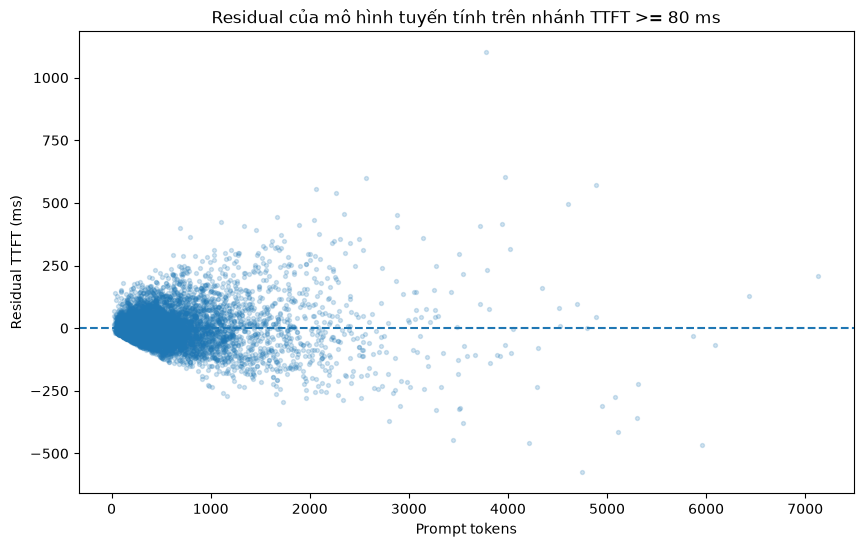

In [34]:
# [ô 34] Kiểm tra residual của mô hình tuyến tính
# trên nhánh TTFT >= 80 ms

upper_predicted = (
    upper_intercept
    + upper_slope * upper_branch["prompt_tokens"]
)

upper_residual = (
    upper_branch["ttft_ms"]
    - upper_predicted
)

plt.figure(figsize=(10, 6))

plt.scatter(
    upper_branch["prompt_tokens"],
    upper_residual,
    s=8,
    alpha=0.20
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel("Prompt tokens")
plt.ylabel("Residual TTFT (ms)")
plt.title("Residual của mô hình tuyến tính trên nhánh TTFT >= 80 ms")

plt.show()

### Nhận xét Ô 34

- **[đo được]** Residual của mô hình tuyến tính trên nhánh TTFT >= 80 ms nhìn chung phân bố quanh mức 0 và không xuất hiện một dạng cong rõ ràng theo `prompt_tokens`.
- **[đo được]** Độ phân tán của residual tăng rõ khi `prompt_tokens` lớn hơn: các prompt ngắn tập trung sát đường residual = 0 hơn, trong khi prompt dài có sai lệch dương và âm lớn hơn.
- **[suy ra]** Quan hệ tuyến tính `TTFT ≈ 89,50 + 0,22385 × prompt_tokens` là một mô tả ban đầu hợp lý cho xu hướng trung tâm của nhánh trên.
- **[suy ra]** Mô hình tuyến tính chưa mô tả đầy đủ độ biến thiên của TTFT; phương sai của residual có vẻ tăng theo độ dài prompt.
- **[phỏng đoán]** Độ biến thiên tăng có thể liên quan đến các yếu tố vận hành khác như batching, queueing hoặc contention, nhưng dữ liệu hiện có chưa cho phép xác định cơ chế cụ thể.

In [35]:
# [ô 35] Định lượng độ phân tán residual
# theo độ dài prompt của nhánh TTFT >= 80 ms

upper_check = upper_branch[
    ["prompt_tokens", "ttft_ms"]
].copy()

upper_check["residual_ms"] = upper_residual

upper_check["prompt_group"] = pd.cut(
    upper_check["prompt_tokens"],
    bins=[0, 500, 1000, 2000, 4000, np.inf],
    labels=[
        "< 500",
        "500–1000",
        "1000–2000",
        "2000–4000",
        ">= 4000"
    ],
    right=False
)

residual_summary = (
    upper_check
    .groupby("prompt_group", observed=True)["residual_ms"]
    .agg(
        n="count",
        q25=lambda x: x.quantile(0.25),
        median="median",
        q75=lambda x: x.quantile(0.75)
    )
)

residual_summary["IQR_residual_ms"] = (
    residual_summary["q75"]
    - residual_summary["q25"]
)

display(residual_summary.round(2))

,n,q25,median,q75,IQR_residual_ms
prompt_group,,,,,
< 500,4649,-30.44,-7.09,22.80,53.24
500–1000,2143,-52.00,-11.87,37.97,89.97
1000–2000,899,-84.72,-10.32,76.39,161.11
2000–4000,222,-119.82,-29.82,96.40,216.22
>= 4000,25,-276.00,-31.10,95.64,371.65


### Nhận xét Ô 35

- **[đo được]** IQR của residual tăng theo độ dài prompt: 53,24 ms với prompt < 500 token; 89,97 ms với 500–1000 token; 161,11 ms với 1000–2000 token; và 216,22 ms với 2000–4000 token.
- **[đo được]** Nhóm >= 4000 token có IQR residual = 371,65 ms nhưng chỉ gồm 25 request, nên kết quả của nhóm này có độ ổn định thấp hơn.
- **[suy ra]** Độ phân tán của TTFT quanh quan hệ tuyến tính tăng rõ khi prompt dài hơn; hình dạng “cái phễu” ở Ô 34 không chỉ do một vài giá trị cực trị.
- **[suy ra]** Đường tuyến tính mô tả được xu hướng trung tâm của nhánh TTFT phía trên nhưng chưa mô tả đầy đủ độ biến thiên.
- **[phỏng đoán]** Prompt dài có thể làm TTFT nhạy hơn với các yếu tố vận hành khác như batching, queueing hoặc contention; dữ liệu hiện có chưa xác định được cơ chế cụ thể.

In [36]:
# [ô 36] Ước lượng tỷ trọng và vị trí của
# hai cấu trúc TTFT chính cùng vùng valley

def summarize_ttft_region(df):
    return pd.Series({
        "n": len(df),
        "percent_all": len(df) / len(requests_ttft) * 100,
        "q25_ms": df["ttft_ms"].quantile(0.25),
        "median_ms": df["ttft_ms"].median(),
        "q75_ms": df["ttft_ms"].quantile(0.75),
        "IQR_ms": (
            df["ttft_ms"].quantile(0.75)
            - df["ttft_ms"].quantile(0.25)
        )
    })

mode_low = requests_ttft[
    requests_ttft["ttft_ms"] < 60
]

valley = requests_ttft[
    (requests_ttft["ttft_ms"] >= 60) &
    (requests_ttft["ttft_ms"] < 80)
]

mode_upper = requests_ttft[
    requests_ttft["ttft_ms"] >= 80
]

mode_summary = pd.DataFrame({
    "Mode thấp (< 60 ms)": summarize_ttft_region(mode_low),
    "Valley (60–80 ms)": summarize_ttft_region(valley),
    "Nhánh trên (>= 80 ms)": summarize_ttft_region(mode_upper)
}).T

display(mode_summary.round(2))

,n,percent_all,q25_ms,median_ms,q75_ms,IQR_ms
Mode thấp (< 60 ms),3401.0,28.76,27.36,34.57,42.64,15.28
Valley (60–80 ms),486.0,4.11,64.49,69.30,74.48,9.99
Nhánh trên (>= 80 ms),7938.0,67.13,130.18,177.33,257.83,127.65


### Nhận xét Ô 36

- **[đo được]** Vùng TTFT < 60 ms gồm 3.401 request, chiếm 28,76% toàn bộ tập; median = 34,57 ms và IQR = 15,28 ms.
- **[đo được]** Vùng 60–80 ms chỉ có 486 request, chiếm 4,11%.
- **[đo được]** Nhánh TTFT >= 80 ms gồm 7.938 request, chiếm 67,13%; median = 177,33 ms và IQR = 127,65 ms.
- **[suy ra]** Mode thấp tập trung hẹp hơn nhiều so với nhánh phía trên, còn vùng 60–80 ms là một vùng mật độ thấp giữa hai cấu trúc chính.
- **[suy ra]** Các tỷ lệ 28,76% và 67,13% mô tả tỷ trọng thực nghiệm của hai vùng, chưa phải trọng số của một mô hình mixture được fit chính thức.

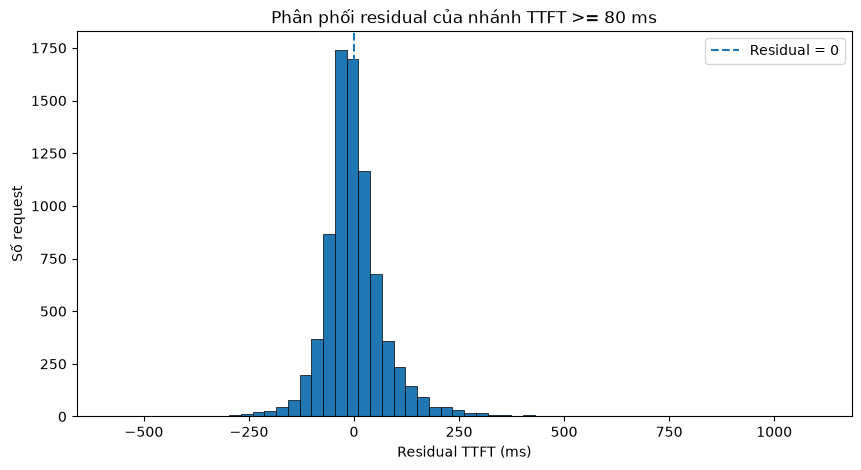

In [37]:
# [ô 37] Quan sát phân phối residual
# của nhánh TTFT >= 80 ms

plt.figure(figsize=(10, 5))

plt.hist(
    upper_residual,
    bins=60,
    edgecolor="black",
    linewidth=0.5
)

plt.axvline(
    0,
    linestyle="--",
    label="Residual = 0"
)

plt.xlabel("Residual TTFT (ms)")
plt.ylabel("Số request")
plt.title("Phân phối residual của nhánh TTFT >= 80 ms")
plt.legend()

plt.show()

In [38]:
# [ô 38] Định lượng hình dạng residual của nhánh TTFT >= 80 ms

residual_shape = pd.Series({
    "n": len(upper_residual),
    "q05_ms": upper_residual.quantile(0.05),
    "q25_ms": upper_residual.quantile(0.25),
    "median_ms": upper_residual.median(),
    "q75_ms": upper_residual.quantile(0.75),
    "q95_ms": upper_residual.quantile(0.95),
    "min_ms": upper_residual.min(),
    "max_ms": upper_residual.max(),
    "skewness": upper_residual.skew(),
    "excess_kurtosis": upper_residual.kurt()
})

display(residual_shape.to_frame("value"))

,value
n,7938.000000
q05_ms,-101.116231
q25_ms,-38.977590
median_ms,-8.218944
q75_ms,30.470246
q95_ms,127.349393
min_ms,-576.217371
max_ms,1100.369757
skewness,1.267157
excess_kurtosis,11.842165


### Nhận xét Ô 38

- **[đo được]** Residual của nhánh TTFT >= 80 ms có median = -8,22 ms, Q05 = -101,12 ms và Q95 = 127,35 ms.
- **[đo được]** Residual có skewness = 1,267 và excess kurtosis = 11,842; giá trị nhỏ nhất là -576,22 ms và lớn nhất là 1100,37 ms.
- **[suy ra]** Residual có bất đối xứng về phía dương và chứa nhiều giá trị cực trị hơn mức được kỳ vọng ở một phân phối Normal đơn giản.
- **[suy ra]** Kết hợp với Ô 35, mô hình tuyến tính mô tả được xu hướng trung tâm của nhánh TTFT phía trên nhưng mô hình `linear + Normal noise với variance cố định` là quá đơn giản.
- **[phỏng đoán]** Các biến vận hành chưa quan sát được như batching, queueing hoặc contention có thể góp phần tạo ra phần biến thiên còn lại.

## Câu 3 — Các con số tóm tắt


In [39]:
# Ô 39 — Point estimates của TTFT cho Câu 3

q3_ttft = requests_ttft["ttft_ms"]

point_estimates = pd.Series({
    "n": q3_ttft.size,
    "mean_ms": q3_ttft.mean(),
    "p50_ms": q3_ttft.quantile(0.50),
    "p90_ms": q3_ttft.quantile(0.90),
    "p99_ms": q3_ttft.quantile(0.99)
})

print(point_estimates.round(3))

n          11825.000
mean_ms      161.449
p50_ms       130.900
p90_ms       324.866
p99_ms       737.139
dtype: float64


### Point estimates của TTFT

**[đo được]** Trên 11.825 request dùng cho phân tích TTFT, các point estimate là: mean = 161.449 ms, p50 = 130.900 ms, p90 = 324.866 ms và p99 = 737.139 ms [ô 39].

**[suy ra]** Mean lớn hơn p50, phù hợp với kết quả trước đó rằng phân phối TTFT có phía giá trị lớn kéo dài. Khoảng cách lớn giữa p50, p90 và p99 cũng cho thấy tail latency đáng kể.

**[suy ra]** Tuy nhiên, các metric tổng hợp này không thể hiện được đầy đủ cấu trúc bimodal đã quan sát ở Câu 2. Vì vậy chưa nên diễn giải mean hoặc p50 như một giá trị đại diện cho một phân phối một mode.


In [40]:
# Ô 40 — So sánh các point estimate của TTFT

mean_ttft = q3_ttft.mean()
p50_ttft = q3_ttft.quantile(0.50)
p90_ttft = q3_ttft.quantile(0.90)
p99_ttft = q3_ttft.quantile(0.99)

comparison = pd.Series({
    "mean_minus_p50_ms": mean_ttft - p50_ttft,
    "mean_vs_p50_pct": (mean_ttft / p50_ttft - 1) * 100,
    "p90_over_p50": p90_ttft / p50_ttft,
    "p99_over_p50": p99_ttft / p50_ttft,
    "p99_over_p90": p99_ttft / p90_ttft
})

print(comparison.round(3))

mean_minus_p50_ms    30.549
mean_vs_p50_pct      23.338
p90_over_p50          2.482
p99_over_p50          5.631
p99_over_p90          2.269
dtype: float64


In [41]:
# Ô 41 — Standard error và CI 95% cho mean TTFT

n = q3_ttft.size
mean_ttft = q3_ttft.mean()

sd_ttft = q3_ttft.std(ddof=1)
se_mean = sd_ttft / np.sqrt(n)

ci_mean_low = mean_ttft - 1.96 * se_mean
ci_mean_high = mean_ttft + 1.96 * se_mean

mean_uncertainty = pd.Series({
    "n": n,
    "mean_ms": mean_ttft,
    "sd_ms": sd_ttft,
    "se_mean_ms": se_mean,
    "ci95_low_ms": ci_mean_low,
    "ci95_high_ms": ci_mean_high
})

print(mean_uncertainty.round(3))

n               11825.000
mean_ms           161.449
sd_ms             149.414
se_mean_ms          1.374
ci95_low_ms       158.756
ci95_high_ms      164.142
dtype: float64


### Mean TTFT và độ bất định

**[đo được]** Mean TTFT là 161.449 ms. Độ lệch chuẩn giữa các request là 149.414 ms, trong khi standard error của mean là 1.374 ms. Khoảng tin cậy 95% theo xấp xỉ Normal cho mean là [158.756, 164.142] ms [ô 41].

**[suy ra]** Mặc dù TTFT của từng request biến thiên mạnh, mean được ước lượng với sampling uncertainty nhỏ hơn do kích thước mẫu lớn. Tuy nhiên, khoảng tin cậy hẹp không có nghĩa mean mô tả tốt toàn bộ phân phối: kết quả Câu 2 cho thấy TTFT có cấu trúc bimodal, lệch phải và có tail dài.

**[suy ra]** Khoảng tin cậy trên cần được hiểu trong phạm vi quá trình lấy mẫu mà dữ liệu hiện tại đại diện; không nên diễn giải nó như một khẳng định về mọi chế độ vận hành của hệ thống.


In [42]:
# Ô 42 — Bootstrap 95% CI cho p50, p90 và p99

rng = np.random.default_rng(42)

x = q3_ttft.to_numpy()
n = len(x)
B = 5000

bootstrap_quantiles = np.empty((B, 3))

for b in range(B):
    sample = rng.choice(x, size=n, replace=True)
    bootstrap_quantiles[b] = np.quantile(
        sample,
        [0.50, 0.90, 0.99]
    )

ci_quantiles = pd.DataFrame(
    {
        "estimate_ms": [
            np.quantile(x, 0.50),
            np.quantile(x, 0.90),
            np.quantile(x, 0.99)
        ],
        "ci95_low_ms": np.percentile(
            bootstrap_quantiles,
            2.5,
            axis=0
        ),
        "ci95_high_ms": np.percentile(
            bootstrap_quantiles,
            97.5,
            axis=0
        )
    },
    index=["p50", "p90", "p99"]
)

print(ci_quantiles.round(3))

     estimate_ms  ci95_low_ms  ci95_high_ms
p50      130.900       128.80       133.040
p90      324.866       318.28       332.580
p99      737.139       692.34       779.844


In [43]:
# Ô 43 — So sánh độ rộng bootstrap CI của các quantile

ci_width = ci_quantiles.copy()

ci_width["ci_width_ms"] = (
    ci_width["ci95_high_ms"]
    - ci_width["ci95_low_ms"]
)

ci_width["relative_ci_width_pct"] = (
    ci_width["ci_width_ms"]
    / ci_width["estimate_ms"]
    * 100
)

print(
    ci_width[
        ["estimate_ms", "ci_width_ms", "relative_ci_width_pct"]
    ].round(3)
)

     estimate_ms  ci_width_ms  relative_ci_width_pct
p50      130.900        4.240                  3.239
p90      324.866       14.300                  4.402
p99      737.139       87.504                 11.871


### So sánh độ rộng confidence interval

**[đo được]** Độ rộng bootstrap 95% CI của p50, p90 và p99 lần lượt là 4.240 ms, 14.300 ms và 87.504 ms. Khi chuẩn hóa theo point estimate, relative CI width tương ứng là 3.239%, 4.402% và 11.871% [ô 43].

**[suy ra]** Uncertainty tăng khi đi sâu về phía tail. Đặc biệt, p99 có khoảng bất định tương đối lớn hơn rõ rệt so với p50 và p90; khác biệt này không chỉ do giá trị tuyệt đối của p99 lớn hơn.

**[suy ra]** Kết quả phù hợp với cấu trúc right-tail dài đã quan sát ở Câu 2, nơi các quantile cao phụ thuộc vào vùng dữ liệu thưa và biến thiên mạnh hơn.


In [44]:
# Ô 44 — Bảng tóm tắt chính thức các metric TTFT của Câu 3

q3_summary = pd.DataFrame({
    "estimate_ms": [
        mean_ttft,
        ci_quantiles.loc["p50", "estimate_ms"],
        ci_quantiles.loc["p90", "estimate_ms"],
        ci_quantiles.loc["p99", "estimate_ms"]
    ],
    "ci95_low_ms": [
        ci_mean_low,
        ci_quantiles.loc["p50", "ci95_low_ms"],
        ci_quantiles.loc["p90", "ci95_low_ms"],
        ci_quantiles.loc["p99", "ci95_low_ms"]
    ],
    "ci95_high_ms": [
        ci_mean_high,
        ci_quantiles.loc["p50", "ci95_high_ms"],
        ci_quantiles.loc["p90", "ci95_high_ms"],
        ci_quantiles.loc["p99", "ci95_high_ms"]
    ],
    "ci_method": [
        "Normal approximation for mean",
        "Percentile bootstrap (B=5000)",
        "Percentile bootstrap (B=5000)",
        "Percentile bootstrap (B=5000)"
    ]
}, index=["mean", "p50", "p90", "p99"])

print(q3_summary.round(3))

      estimate_ms  ci95_low_ms  ci95_high_ms                      ci_method
mean      161.449      158.756       164.142  Normal approximation for mean
p50       130.900      128.800       133.040  Percentile bootstrap (B=5000)
p90       324.866      318.280       332.580  Percentile bootstrap (B=5000)
p99       737.139      692.340       779.844  Percentile bootstrap (B=5000)


### Kết luận Câu 3 — Các con số tóm tắt

**[đo được]** Trên 11.825 request dùng cho phân tích TTFT, mean = 161.449 ms với 95% CI [158.756, 164.142] ms; p50 = 130.900 ms với 95% bootstrap CI [128.800, 133.040] ms; p90 = 324.866 ms với CI [318.280, 332.580] ms; và p99 = 737.139 ms với CI [692.340, 779.844] ms [ô 44].

**[đo được]** Mean cao hơn p50 30.549 ms, tương đương 23.338%; p90 lớn gấp 2.482 lần p50 và p99 lớn gấp 5.631 lần p50 [ô 40].

**[suy ra]** Mean là metric dễ gây hiểu nhầm nhất nếu được diễn giải như TTFT “điển hình”. Phân phối TTFT đã được phát hiện là lệch phải và bimodal: 28.76% request thuộc vùng dưới 60 ms với median 34.57 ms, trong khi 67.13% thuộc nhánh từ 80 ms trở lên với median 177.33 ms [ô 36]. Một mean duy nhất trộn hai chế độ này và đồng thời chịu ảnh hưởng của tail phải dài.

**[suy ra]** P50 ít nhạy với các giá trị cực trị hơn mean, nhưng nếu báo cáo riêng p50 cũng không thể hiện được cấu trúc bimodal. Vì vậy mean và p50 nên được đọc cùng với mô tả phân phối ở Câu 2, còn p90 và p99 bổ sung thông tin về tail latency.

**[đo được]** Relative width của bootstrap 95% CI lần lượt là 3.239% đối với p50, 4.402% đối với p90 và 11.871% đối với p99 [ô 43].

**[suy ra]** P99 có sampling uncertainty tương đối lớn hơn rõ rệt so với p50 và p90. Điều này phù hợp với việc p99 phụ thuộc vào vùng tail thưa hơn của phân phối.

Khoảng tin cậy của mean được tính bằng xấp xỉ Normal cho sampling distribution của mean. Các confidence interval của p50, p90 và p99 được ước lượng bằng percentile bootstrap với 5.000 lần resample. Các khoảng này định lượng sampling uncertainty theo giả định quá trình resample từng request là một xấp xỉ phù hợp; chúng không phải là khoảng chứa 95% request.

## Câu 4 — Cần bao nhiêu số đo?


In [45]:
# Ô 45 - Xác định empirical reference cho thí nghiệm sample size

ttft_population = requests_ttft["ttft_ms"].to_numpy()

N_population = len(ttft_population)

reference_p99 = np.percentile(ttft_population, 99)

relative_error_target = 0.10

lower_bound = reference_p99 * (1 - relative_error_target)
upper_bound = reference_p99 * (1 + relative_error_target)

print("Empirical population size:", N_population)
print(f"Reference p99: {reference_p99:.3f} ms")
print(f"Target relative error: ±{relative_error_target * 100:.0f}%")
print(f"Success interval: [{lower_bound:.3f}, {upper_bound:.3f}] ms")

Empirical population size: 11825
Reference p99: 737.139 ms
Target relative error: ±10%
Success interval: [663.425, 810.853] ms


In [46]:
# Ô 46 - Minh họa một trial của thí nghiệm sample size

rng = np.random.default_rng(2026)

n = 500

sample_ttft = rng.choice(
    ttft_population,
    size=n,
    replace=False
)

sample_p99 = np.percentile(sample_ttft, 99)

relative_error = abs(sample_p99 - reference_p99) / reference_p99

success = relative_error <= relative_error_target

print("Sample size n:", n)
print(f"Sample p99: {sample_p99:.3f} ms")
print(f"Reference p99: {reference_p99:.3f} ms")
print(f"Relative error: {relative_error * 100:.2f}%")
print("Success:", success)

Sample size n: 500
Sample p99: 707.315 ms
Reference p99: 737.139 ms
Relative error: 4.05%
Success: True


In [47]:
# Ô 47 - Lặp nhiều trial cho cùng sample size n = 500

rng = np.random.default_rng(2026)

n = 500
n_trials = 1000

sample_p99_values = []
relative_errors = []
successes = []

for _ in range(n_trials):
    sample_ttft = rng.choice(
        ttft_population,
        size=n,
        replace=False
    )

    sample_p99 = np.percentile(sample_ttft, 99)

    relative_error = abs(sample_p99 - reference_p99) / reference_p99

    success = relative_error <= relative_error_target

    sample_p99_values.append(sample_p99)
    relative_errors.append(relative_error)
    successes.append(success)

success_rate = np.mean(successes)

print("Sample size n:", n)
print("Number of trials:", n_trials)
print(f"Success rate: {success_rate * 100:.2f}%")

print()
print("Distribution of estimated p99 across trials:")
print(f"5th percentile : {np.percentile(sample_p99_values, 5):.3f} ms")
print(f"Median         : {np.percentile(sample_p99_values, 50):.3f} ms")
print(f"95th percentile: {np.percentile(sample_p99_values, 95):.3f} ms")

Sample size n: 500
Number of trials: 1000
Success rate: 60.90%

Distribution of estimated p99 across trials:
5th percentile : 600.837 ms
Median         : 709.884 ms
95th percentile: 857.317 ms


**[đo được]** Với sample size `n = 500`, 1.000 lần resampling không hoàn lại cho success rate 60.90%, trong đó success được định nghĩa là p99 estimate có relative error không quá ±10% so với empirical reference p99 = 737.139 ms. Phân vị 5%, median và 95% của các p99 estimate lần lượt là 600.837 ms, 709.884 ms và 857.317 ms.

**[suy ra]** Một sample size 500 request chưa cho p99 đủ ổn định nếu sử dụng tiêu chí thiết kế yêu cầu ít nhất 95% trial đạt sai số ±10%. Kết quả một trial đơn lẻ không đủ để đánh giá sample size: Ô 46 tình cờ đạt error 4.05%, nhưng khi lặp 1.000 lần thì 39.10% trial không đạt yêu cầu.


In [48]:
# Ô 48 - Coarse scan success rate theo sample size

sample_sizes = [100, 200, 500, 1000, 1500, 2000, 2500, 3000]

n_trials = 1000

results = []

for n in sample_sizes:
    rng = np.random.default_rng(2026)

    successes = []

    for _ in range(n_trials):
        sample_ttft = rng.choice(
            ttft_population,
            size=n,
            replace=False
        )

        sample_p99 = np.percentile(sample_ttft, 99)

        relative_error = abs(sample_p99 - reference_p99) / reference_p99

        success = relative_error <= relative_error_target

        successes.append(success)

    success_rate = np.mean(successes)

    results.append({
        "n": n,
        "success_rate": success_rate
    })

results_df = pd.DataFrame(results)

results_df["success_rate_percent"] = (
    results_df["success_rate"] * 100
)

print(results_df[["n", "success_rate_percent"]])

      n  success_rate_percent
0   100                  26.4
1   200                  37.1
2   500                  60.9
3  1000                  75.7
4  1500                  87.0
5  2000                  92.3
6  2500                  95.3
7  3000                  97.6


**[đo được]** Trong coarse scan với 1.000 trials cho mỗi sample size, success rate tăng từ 26.4% tại `n = 100` lên 97.6% tại `n = 3000`. Với tiêu chí thiết kế success rate ≥95%, `n = 2000` đạt 92.3% và `n = 2500` đạt 95.3%.

**[suy ra]** Ngưỡng sample size cần tìm nằm trong vùng khoảng 2.000–2.500 request. Chưa chọn `n = 2500` làm kết quả cuối vì grid hiện tại còn thô và success rate 95.3% nằm rất gần ngưỡng 95%, nên cần fine scan và kiểm tra độ ổn định của simulation.


In [49]:
# Ô 49 - Fine scan vùng sample size 2000–2500

sample_sizes_fine = [2000, 2100, 2200, 2300, 2400, 2500]

n_trials = 1000

fine_results = []

for n in sample_sizes_fine:
    rng = np.random.default_rng(2026)

    successes = []

    for _ in range(n_trials):
        sample_ttft = rng.choice(
            ttft_population,
            size=n,
            replace=False
        )

        sample_p99 = np.percentile(sample_ttft, 99)

        relative_error = abs(sample_p99 - reference_p99) / reference_p99

        success = relative_error <= relative_error_target

        successes.append(success)

    success_rate = np.mean(successes)

    fine_results.append({
        "n": n,
        "success_rate_percent": success_rate * 100
    })

fine_results_df = pd.DataFrame(fine_results)

print(fine_results_df)

      n  success_rate_percent
0  2000                  92.3
1  2100                  92.7
2  2200                  94.1
3  2300                  94.6
4  2400                  96.3
5  2500                  95.3


**[đo được]** Fine scan trong vùng 2.000–2.500 request với 1.000 trials cho mỗi sample size cho success rate lần lượt là 92.3%, 92.7%, 94.1%, 94.6%, 96.3% và 95.3%. Với tiêu chí thiết kế success rate ≥95%, vùng chuyển tiếp nằm khoảng giữa `n = 2300` và `n = 2400`.

**[suy ra]** Ngưỡng sample size có vẻ ở khoảng 2.4 nghìn request, nhưng chưa nên chốt từ 1.000 trials vì các success rate gần ngưỡng 95% còn chịu Monte Carlo noise. Việc `n = 2400` cho 96.3% nhưng `n = 2500` cho 95.3% là một dấu hiệu cho thấy cần tăng số lần lặp để kiểm tra độ ổn định quanh vùng ngưỡng.


In [50]:
# Ô 50 - Kiểm tra stability bằng cách tăng số Monte Carlo trials

sample_sizes_stability = [2200, 2300, 2400, 2500]

n_trials_stability = 5000

stability_results = []

for n in sample_sizes_stability:
    rng = np.random.default_rng(2026)

    successes = []

    for _ in range(n_trials_stability):
        sample_ttft = rng.choice(
            ttft_population,
            size=n,
            replace=False
        )

        sample_p99 = np.percentile(sample_ttft, 99)

        relative_error = abs(sample_p99 - reference_p99) / reference_p99

        success = relative_error <= relative_error_target

        successes.append(success)

    success_rate = np.mean(successes)

    stability_results.append({
        "n": n,
        "n_trials": n_trials_stability,
        "success_rate_percent": success_rate * 100
    })

stability_results_df = pd.DataFrame(stability_results)

print(stability_results_df)

      n  n_trials  success_rate_percent
0  2200      5000                 94.04
1  2300      5000                 94.56
2  2400      5000                 95.14
3  2500      5000                 95.28


**[đo được]** Khi tăng số Monte Carlo trials từ 1.000 lên 5.000 cho vùng sample size gần ngưỡng, success rate tại `n = 2200`, `2300`, `2400` và `2500` lần lượt là 94.04%, 94.56%, 95.14% và 95.28%. Success được định nghĩa là p99 estimate có relative error không quá ±10% so với empirical reference p99 = 737.139 ms.

**[suy ra]** Với tiêu chí thiết kế success rate ≥95%, vùng chuyển tiếp hiện nằm khoảng 2.300–2.400 request. Việc tăng số trial làm kết quả ổn định hơn so với fine scan 1.000 trials, nhưng `n = 2400` chỉ vượt ngưỡng 95% một khoảng nhỏ nên cần kiểm tra thêm độ nhạy với random seed trước khi chốt sample size.


In [51]:
# Ô 51 - Kiểm tra độ nhạy của success rate với random seed

sample_sizes_seed = [2300, 2400, 2500, 2600]
seeds = [2026, 2027, 2028, 2029, 2030]

n_trials_seed = 3000

seed_results = []

for seed in seeds:
    for n in sample_sizes_seed:
        rng = np.random.default_rng(seed)

        successes = []

        for _ in range(n_trials_seed):
            sample_ttft = rng.choice(
                ttft_population,
                size=n,
                replace=False
            )

            sample_p99 = np.percentile(sample_ttft, 99)

            relative_error = (
                abs(sample_p99 - reference_p99)
                / reference_p99
            )

            success = relative_error <= relative_error_target

            successes.append(success)

        success_rate = np.mean(successes)

        seed_results.append({
            "seed": seed,
            "n": n,
            "success_rate_percent": success_rate * 100
        })

seed_results_df = pd.DataFrame(seed_results)

seed_pivot = seed_results_df.pivot(
    index="seed",
    columns="n",
    values="success_rate_percent"
)

print(seed_pivot.round(2))

n      2300   2400   2500   2600
seed                            
2026  94.23  94.97  95.40  95.97
2027  94.00  94.97  95.53  96.53
2028  94.17  95.23  94.97  95.90
2029  94.20  94.60  95.60  95.97
2030  94.87  95.07  95.67  96.33


**[đo được]** Khi lặp thí nghiệm với 5 random seed khác nhau, mỗi seed gồm 3.000 trials, `n = 2300` luôn cho success rate dưới 95%; `n = 2400` dao động quanh ngưỡng 95%; `n = 2500` hầu hết nằm trên 95%, còn `n = 2600` đều nằm trên 95%.

**[suy ra]** Việc đổi random seed làm success rate thay đổi nhẹ nhưng không làm vùng sample size cần thiết thay đổi mạnh: vùng chuyển tiếp vẫn nằm khoảng 2.4–2.5 nghìn request. Vì `n = 2400` nằm ngay sát ngưỡng thiết kế, khoảng 2.500 request là ứng viên hợp lý hơn để báo cáo, nhưng cần tổng hợp kết quả qua các seed trước khi chốt.


In [52]:
# Ô 52 - Tổng hợp seed stability

seed_summary = (
    seed_results_df
    .groupby("n")["success_rate_percent"]
    .agg(
        mean_success_rate="mean",
        min_success_rate="min",
        max_success_rate="max"
    )
    .reset_index()
)

seed_summary["seed_range_pp"] = (
    seed_summary["max_success_rate"]
    - seed_summary["min_success_rate"]
)

seed_summary["meets_95_percent"] = (
    seed_summary["mean_success_rate"] >= 95
)

print(seed_summary.round(2))

      n  mean_success_rate  min_success_rate  max_success_rate  seed_range_pp  \
0  2300              94.29             94.00             94.87           0.87   
1  2400              94.97             94.60             95.23           0.63   
2  2500              95.43             94.97             95.67           0.70   
3  2600              96.14             95.90             96.53           0.63   

   meets_95_percent  
0             False  
1             False  
2              True  
3              True  


**[đo được]** Tổng hợp 5 random seed, mỗi seed gồm 3.000 Monte Carlo trials, cho mean success rate lần lượt là 94.29%, 94.97%, 95.43% và 96.14% tại `n = 2300`, `2400`, `2500` và `2600`. Biên độ success rate giữa các seed chỉ khoảng 0.63–0.87 điểm phần trăm.

**[suy ra]** Kết luận không phụ thuộc mạnh vào một random seed cụ thể: vùng chuyển tiếp quanh criterion 95% vẫn nằm khoảng 2.4–2.5 nghìn request. Theo tiêu chí thiết kế đã chọn, khoảng 2.5 nghìn request là mức hợp lý để báo cáo, thay vì coi 2.500 là một ngưỡng chính xác tuyệt đối.


In [53]:
# Ô 53 - Robustness check: sampling có hoàn lại

sample_sizes_replacement = [2400, 2500, 3000, 3500]

n_trials_replacement = 5000

replacement_results = []

for n in sample_sizes_replacement:
    rng = np.random.default_rng(2026)

    successes = []

    for _ in range(n_trials_replacement):
        sample_ttft = rng.choice(
            ttft_population,
            size=n,
            replace=True
        )

        sample_p99 = np.percentile(sample_ttft, 99)

        relative_error = (
            abs(sample_p99 - reference_p99)
            / reference_p99
        )

        success = relative_error <= relative_error_target

        successes.append(success)

    success_rate = np.mean(successes)

    replacement_results.append({
        "n": n,
        "replace": True,
        "n_trials": n_trials_replacement,
        "success_rate_percent": success_rate * 100
    })

replacement_results_df = pd.DataFrame(replacement_results)

print(replacement_results_df)

      n  replace  n_trials  success_rate_percent
0  2400     True      5000                 91.30
1  2500     True      5000                 92.76
2  3000     True      5000                 95.18
3  3500     True      5000                 97.00


**[đo được]** Khi chuyển từ sampling không hoàn lại sang sampling có hoàn lại, success rate tại `n = 2400` và `n = 2500` giảm còn 91.30% và 92.76%. `n = 3000` đạt 95.18% và `n = 3500` đạt 97.00%.

**[suy ra]** Kết quả sample-size có độ nhạy đáng kể với cách mô hình hóa quá trình lấy mẫu. Sampling không hoàn lại mô phỏng việc chỉ quan sát một subset của chính 11.825 request hiện có và được hưởng finite-population effect khi sample chiếm phần đáng kể của dataset. Sampling có hoàn lại phù hợp hơn nếu coi 11.825 request là empirical distribution để mô phỏng một measurement run mới. Theo cách diễn giải thứ hai, sample size cần thiết nằm gần 3.000 request thay vì khoảng 2.500.

**[suy ra]** Vì Câu 4 hướng tới tình huống chỉ thu được một số lượng request hạn chế trong một measurement campaign, em ưu tiên kết quả khoảng 3.000 request làm câu trả lời thực hành, đồng thời báo cáo khoảng 2.500 request là kết quả sensitivity khi subsample không hoàn lại từ chính cửa sổ dữ liệu hiện tại.


In [54]:
# Ô 54 - Final stability check quanh threshold với replace=True

sample_sizes_final = [2800, 2900, 3000, 3100, 3200]
seeds_final = [2026, 2027, 2028, 2029, 2030]

n_trials_final = 3000

final_results = []

for seed in seeds_final:
    for n in sample_sizes_final:
        rng = np.random.default_rng(seed)

        successes = []

        for _ in range(n_trials_final):
            sample_ttft = rng.choice(
                ttft_population,
                size=n,
                replace=True
            )

            sample_p99 = np.percentile(sample_ttft, 99)

            relative_error = (
                abs(sample_p99 - reference_p99)
                / reference_p99
            )

            success = relative_error <= relative_error_target

            successes.append(success)

        success_rate = np.mean(successes)

        final_results.append({
            "seed": seed,
            "n": n,
            "success_rate_percent": success_rate * 100
        })

final_results_df = pd.DataFrame(final_results)

final_summary = (
    final_results_df
    .groupby("n")["success_rate_percent"]
    .agg(
        mean_success_rate="mean",
        min_success_rate="min",
        max_success_rate="max"
    )
    .reset_index()
)

print(final_summary.round(2))

      n  mean_success_rate  min_success_rate  max_success_rate
0  2800              94.30             93.90             94.67
1  2900              94.98             94.63             95.33
2  3000              95.24             94.77             95.47
3  3100              95.60             95.33             96.00
4  3200              95.99             95.63             96.37


### Kết luận Câu 4 — Cần bao nhiêu số đo?

**[đo được]** Em dùng 11.825 request hợp lệ cho TTFT làm empirical population. p99 trên toàn bộ tập này là 737.139 ms [ô 45]. Em sử dụng giá trị này làm empirical reference cho thí nghiệm sample-size. Sai số ±10% được định nghĩa là relative error của sample p99 so với reference p99 không vượt quá 10%, tương ứng sample p99 nằm trong khoảng 663.425–810.853 ms [ô 45].

Một trial gồm việc lấy ngẫu nhiên `n` request từ empirical distribution, tính p99 và đánh dấu trial là thành công nếu relative error không quá 10%. Một trial đơn lẻ không đủ để đánh giá sample size: với `n = 500`, một trial cho error 4.05% [ô 46], nhưng khi lặp 1.000 lần thì success rate chỉ đạt 60.90% [ô 47].

Em chọn **success rate ≥95%** làm tiêu chí thiết kế để gọi một sample size là đủ ổn định. Đây là tiêu chí do em lựa chọn, không phải ngưỡng được đề bài cho sẵn.

**[đo được]** Coarse và fine subsampling không hoàn lại xác định vùng chuyển tiếp ban đầu khoảng 2.4–2.5 nghìn request [ô 48–52]. Tuy nhiên, ở kích thước này sample đã chiếm tỷ lệ đáng kể của empirical population. Khi dùng sampling có hoàn lại để mô phỏng các measurement runs mới từ empirical distribution, `n = 2500` chỉ đạt success rate 92.76%, trong khi `n = 3000` đạt 95.18% trong 5.000 trials [ô 53].

**[đo được]** Kiểm tra cuối với 5 random seed và 3.000 trials mỗi seed cho thấy mean success rate tại `n = 2800`, `2900`, `3000`, `3100` và `3200` lần lượt là 94.30%, 94.98%, 95.24%, 95.60% và 95.99% [ô 54].

**[suy ra]** Với empirical distribution của dataset hiện tại và tiêu chí yêu cầu khoảng 95% simulated measurements ước lượng p99 trong ±10% reference, cần **khoảng 3.000 request**. Con số này nên được hiểu là một kết quả empirical gần đúng, không phải ngưỡng chính xác hay hằng số chung cho mọi hệ thống.

**[suy ra]** Kết quả có độ nhạy với cách mô hình hóa sampling: subsampling không hoàn lại từ chính cửa sổ dữ liệu cho ngưỡng khoảng 2.5 nghìn, trong khi sampling có hoàn lại cho ngưỡng gần 3 nghìn. Em ưu tiên kết quả khoảng 3 nghìn cho câu trả lời chính vì nó phù hợp hơn với việc mô phỏng một measurement run mới từ empirical distribution.

**[suy ra]** Thí nghiệm giả định các request có thể được resample như các draws từ cùng một distribution. Dataset hiện tại không cung cấp đủ thông tin về batch, scheduler, worker, queue hoặc các dependence theo thời gian, vì vậy sample-size này có thể thay đổi nếu workload hoặc cơ chế hệ thống thay đổi.

## Câu 5 — Một hình


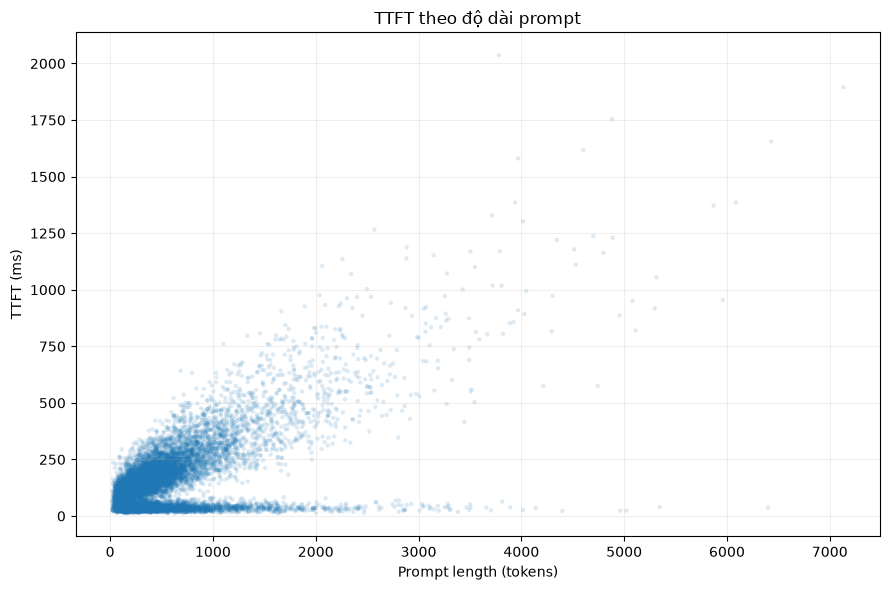

In [55]:
# Ô 55 — Candidate 1: TTFT theo độ dài prompt

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    requests_ttft["prompt_tokens"],
    requests_ttft["ttft_ms"],
    s=10,
    alpha=0.15,
    edgecolors="none"
)

ax.set_title("TTFT theo độ dài prompt")
ax.set_xlabel("Prompt length (tokens)")
ax.set_ylabel("TTFT (ms)")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

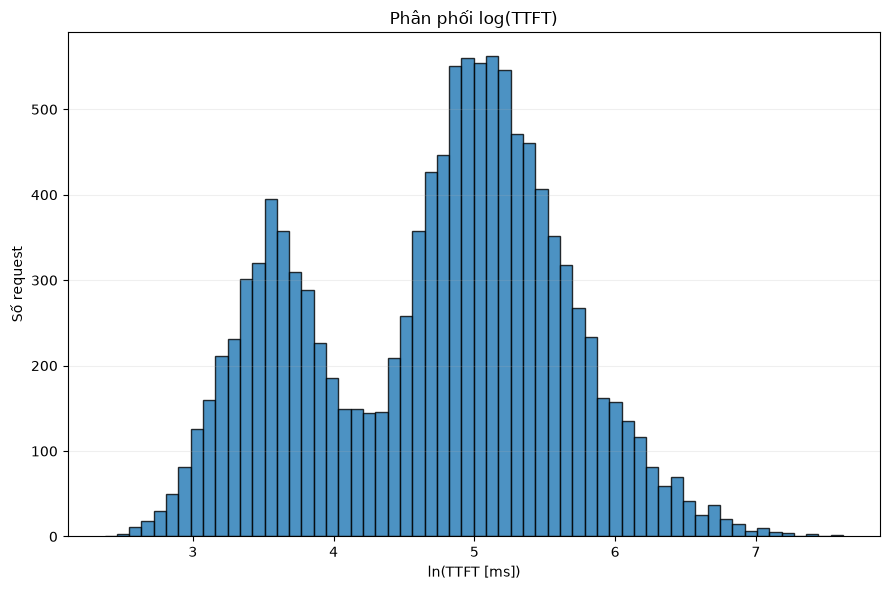

In [56]:
# Ô 56 — Candidate 2: phân phối log(TTFT)

log_ttft = np.log(requests_ttft["ttft_ms"])

fig, ax = plt.subplots(figsize=(9, 6))

ax.hist(
    log_ttft,
    bins=60,
    edgecolor="black",
    alpha=0.8
)

ax.set_title("Phân phối log(TTFT)")
ax.set_xlabel("ln(TTFT [ms])")
ax.set_ylabel("Số request")

ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

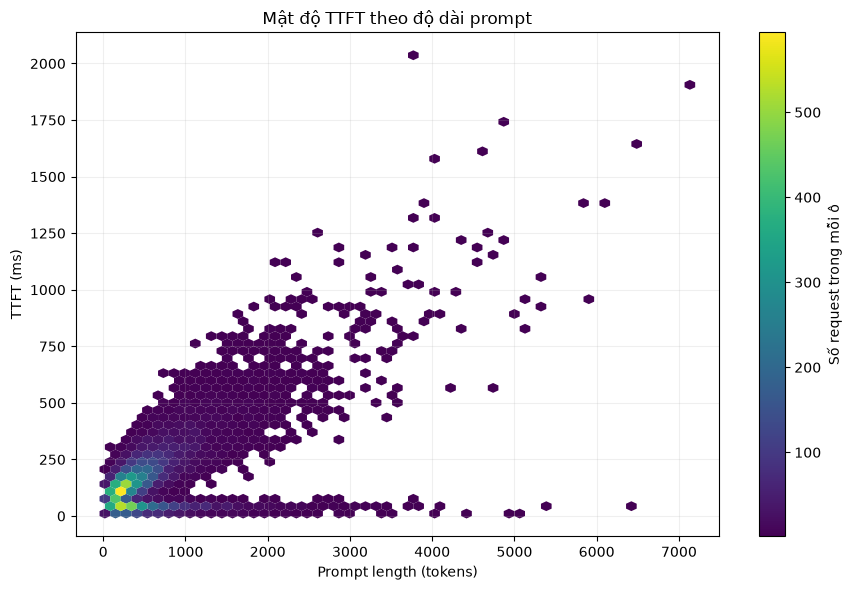

In [57]:
# Ô 57 — Candidate 3: mật độ TTFT theo độ dài prompt bằng hexbin

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 6))

hb = ax.hexbin(
    requests_ttft["prompt_tokens"],
    requests_ttft["ttft_ms"],
    gridsize=55,
    mincnt=1,
    linewidths=0
)

cbar = fig.colorbar(hb, ax=ax)
cbar.set_label("Số request trong mỗi ô")

ax.set_title("Mật độ TTFT theo độ dài prompt")
ax.set_xlabel("Prompt length (tokens)")
ax.set_ylabel("TTFT (ms)")

ax.grid(alpha=0.2)

plt.tight_layout()
plt.show()

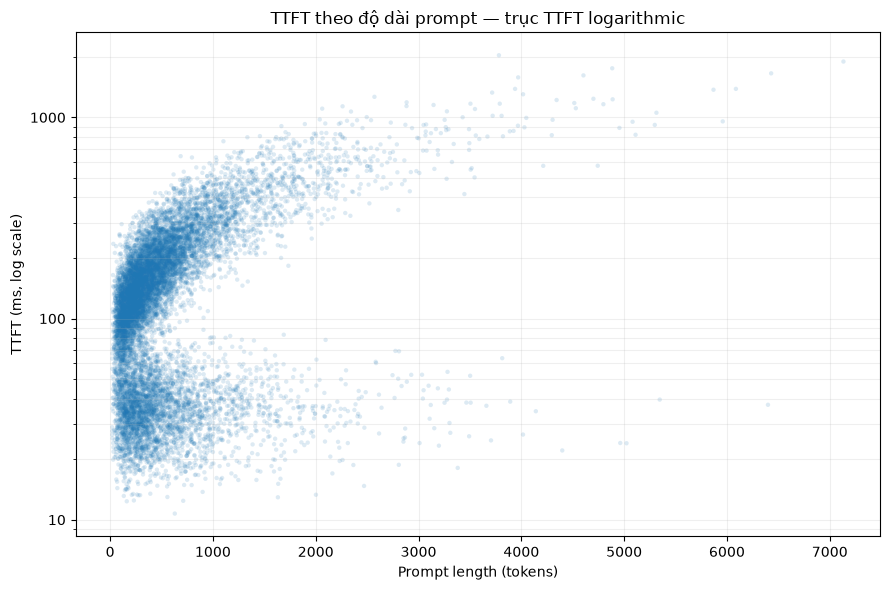

In [58]:
# Ô 58 — Candidate 4:
# Scatter TTFT theo prompt length với trục Y logarithmic

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    requests_ttft["prompt_tokens"],
    requests_ttft["ttft_ms"],
    s=10,
    alpha=0.15,
    edgecolors="none"
)

# Chỉ thay đổi cách biểu diễn trục Y,
# không loại bỏ bất kỳ request nào
ax.set_yscale("log")

# Hiển thị tick dưới dạng ms quen thuộc thay vì 10^1, 10^2, ...
ax.yaxis.set_major_formatter(ScalarFormatter())

ax.set_title("TTFT theo độ dài prompt — trục TTFT logarithmic")
ax.set_xlabel("Prompt length (tokens)")
ax.set_ylabel("TTFT (ms, log scale)")

ax.grid(alpha=0.2, which="both")

plt.tight_layout()
plt.show()

In [59]:
# Ô 59 — Kiểm tra định lượng pattern đang thấy trên scatter

plot_check = requests_ttft.copy()

# Chia prompt length thành các khoảng để chỉ kiểm tra pattern,
# không dùng các khoảng này để vẽ final figure.
prompt_bins = [0, 250, 500, 1000, 2000, 4000, float("inf")]
prompt_labels = [
    "0–250",
    "251–500",
    "501–1000",
    "1001–2000",
    "2001–4000",
    ">4000"
]

plot_check["prompt_bin"] = pd.cut(
    plot_check["prompt_tokens"],
    bins=prompt_bins,
    labels=prompt_labels,
    include_lowest=True
)

plot_check["ttft_region"] = pd.cut(
    plot_check["ttft_ms"],
    bins=[0, 60, 80, float("inf")],
    labels=["<60 ms", "60–80 ms", ">=80 ms"],
    include_lowest=True,
    right=False
)

pattern_summary = (
    plot_check
    .groupby(
        ["prompt_bin", "ttft_region"],
        observed=True
    )
    .agg(
        n=("ttft_ms", "size"),
        median_ttft_ms=("ttft_ms", "median")
    )
    .reset_index()
)

print(pattern_summary.to_string(index=False))

prompt_bin ttft_region    n  median_ttft_ms
     0–250      <60 ms 1040          35.005
     0–250    60–80 ms  309          70.290
     0–250     >=80 ms 2062         121.080
   251–500      <60 ms 1087          34.190
   251–500    60–80 ms  105          66.670
   251–500     >=80 ms 2595         159.530
  501–1000      <60 ms  810          33.795
  501–1000    60–80 ms   51          66.090
  501–1000     >=80 ms 2137         228.540
 1001–2000      <60 ms  371          35.750
 1001–2000    60–80 ms   14          67.720
 1001–2000     >=80 ms  897         375.420
 2001–4000      <60 ms   86          34.865
 2001–4000    60–80 ms    7          63.540
 2001–4000     >=80 ms  222         616.795
     >4000      <60 ms    7          26.510
     >4000     >=80 ms   25        1110.610


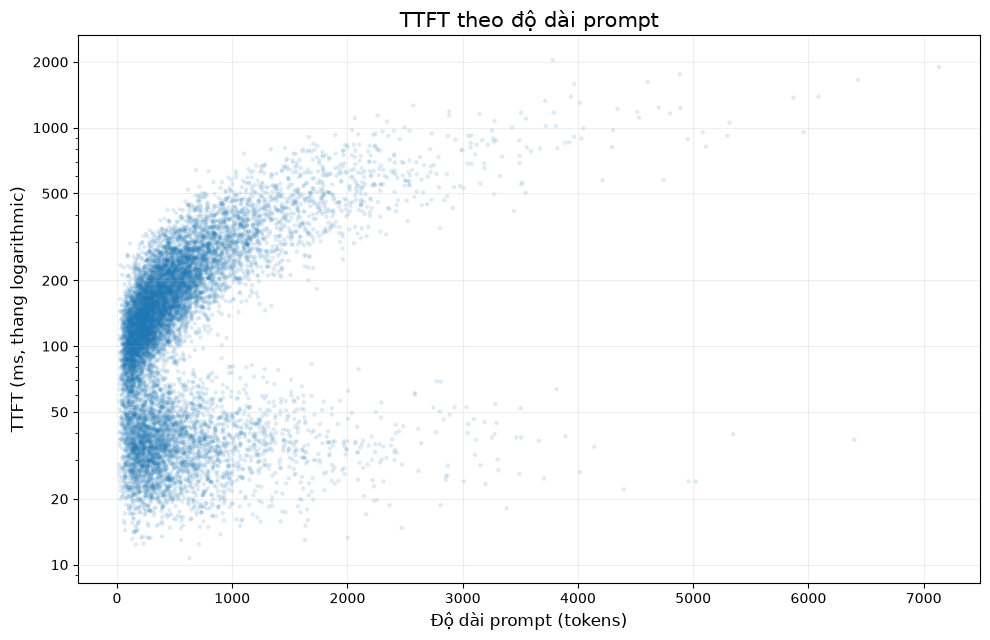

In [60]:
# Ô 60 — Final candidate cho Câu 5
# Scatter TTFT theo prompt length, giữ toàn bộ tail và dùng log scale ở trục Y

import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

fig, ax = plt.subplots(figsize=(10, 6.5))

ax.scatter(
    requests_ttft["prompt_tokens"],
    requests_ttft["ttft_ms"],
    s=10,
    alpha=0.14,
    edgecolors="none"
)

ax.set_yscale("log")

# Các mốc latency quen thuộc để người xem vẫn đọc được đơn vị ms
yticks = [10, 20, 50, 100, 200, 500, 1000, 2000]
ax.set_yticks(yticks)
ax.yaxis.set_major_formatter(ScalarFormatter())
ax.yaxis.set_minor_formatter(plt.NullFormatter())

ax.set_title(
    "TTFT theo độ dài prompt",
    fontsize=15
)

ax.set_xlabel(
    "Độ dài prompt (tokens)",
    fontsize=12
)

ax.set_ylabel(
    "TTFT (ms, thang logarithmic)",
    fontsize=12
)

ax.grid(
    alpha=0.20,
    which="major"
)

plt.tight_layout()

# File sản phẩm của Câu 5
plt.savefig(
    "hinh.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [61]:
# Ô 61 — Kiểm tra file hinh.png đã được lưu

from pathlib import Path

figure_path = Path("hinh.png")

print("Tồn tại:", figure_path.exists())

if figure_path.exists():
    print("Đường dẫn:", figure_path.resolve())
    print("Kích thước:", figure_path.stat().st_size, "bytes")

Tồn tại: True
Đường dẫn: C:\Users\Admin\Desktop\Nexus Lab\Measure_latency\hinh.png
Kích thước: 809681 bytes


In [62]:
print("Hết câu 4")

Hết câu 4


### Kết luận Câu 5 — Một hình

Hình cuối được chọn là scatter plot giữa độ dài prompt và TTFT, với TTFT biểu diễn trên thang logarithmic.

**[đo được]** Hình cho thấy một vùng TTFT thấp kéo dài qua nhiều độ dài prompt, trong khi nhánh TTFT phía trên tăng rõ khi prompt dài hơn; các request có TTFT trên 1000–2000 ms vẫn được giữ trong hình.

**[suy ra]** Em chọn scatter plot TTFT theo độ dài prompt vì nó cho thấy đồng thời hai pattern quan trọng: một vùng TTFT thấp gần như không thay đổi theo prompt length và một nhánh TTFT cao tăng rõ khi prompt dài hơn.  
**[suy ra]** Histogram log(TTFT) làm bimodality rõ hơn nhưng loại bỏ thông tin về prompt length, còn hexbin xử lý overplotting tốt hơn nhưng làm các request hiếm trong long tail kém nổi bật.  
**[suy ra]** Em dùng trục TTFT logarithmic để giữ toàn bộ long tail mà vẫn nhìn rõ vùng latency thấp, chấp nhận rằng khoảng cách trên trục Y không còn biểu diễn chênh lệch millisecond theo thang tuyến tính.

**[phỏng đoán]** Hai pattern này có thể phản ánh các chế độ xử lý request khác nhau, nhưng dữ liệu hiện có không đủ để xác định nguyên nhân cụ thể như cache hit, prefix reuse hay một fast path.

## Câu 6 — Những điều chưa xác định được


In [63]:
# Ô 63 — Kiểm tra cấu trúc cơ bản của tokens.csv

print("=== KÍCH THƯỚC VÀ PHẠM VI REQUEST ===")
print("Shape:", tokens.shape)
print("Số request_id duy nhất:", tokens["request_id"].nunique())

print("\n=== CÁC CỘT ===")
print(tokens.columns.tolist())

print("\n=== 5 DÒNG ĐẦU ===")
print(tokens.head())

print("\n=== TOKEN_INDEX ===")
print("Min token_index:", tokens["token_index"].min())
print("Max token_index:", tokens["token_index"].max())
print("Số token_index <= 0:", (tokens["token_index"] <= 0).sum())

print("\n=== ITL_MS ===")
print("Số NaN:", tokens["itl_ms"].isna().sum())
print("Số itl_ms <= 0:", (tokens["itl_ms"] <= 0).sum())

print("\nMô tả itl_ms:")
print(
    tokens["itl_ms"].describe(
        percentiles=[0.05, 0.25, 0.5, 0.75, 0.90, 0.95, 0.99]
    )
)

=== KÍCH THƯỚC VÀ PHẠM VI REQUEST ===
Shape: (1829816, 3)
Số request_id duy nhất: 11825

=== CÁC CỘT ===
['request_id', 'token_index', 'itl_ms']

=== 5 DÒNG ĐẦU ===
  request_id  token_index  itl_ms
0    r100000            1   8.860
1    r100000            2   6.178
2    r100000            3  10.039
3    r100000            4   7.954
4    r100000            5   9.444

=== TOKEN_INDEX ===
Min token_index: 1
Max token_index: 899
Số token_index <= 0: 0

=== ITL_MS ===
Số NaN: 0
Số itl_ms <= 0: 0

Mô tả itl_ms:
count    1.829816e+06
mean     1.557855e+01
std      9.209571e+00
min      7.060000e-01
5%       4.915000e+00
25%      8.187000e+00
50%      1.302300e+01
75%      2.152200e+01
90%      2.876500e+01
95%      3.313000e+01
99%      4.190600e+01
max      9.203500e+01
Name: itl_ms, dtype: float64


In [64]:
# Ô 64 — Đối chiếu tokens.csv với request-level data

# Đếm số dòng token của từng request
token_counts = (
    tokens.groupby("request_id")
    .size()
    .rename("token_rows")
    .reset_index()
)

# Dùng requests_work vì đây là bảng request đã loại duplicate
token_check = requests_work[
    ["request_id", "status", "output_tokens"]
].merge(
    token_counts,
    on="request_id",
    how="left"
)

# Request không xuất hiện trong tokens.csv sẽ có NaN -> 0 dòng token
token_check["token_rows"] = token_check["token_rows"].fillna(0).astype(int)

# Theo mô tả đề:
# tokens.csv chỉ chứa các token sau token đầu tiên
token_check["expected_token_rows"] = (
    token_check["output_tokens"] - 1
).clip(lower=0)

token_check["row_count_match"] = (
    token_check["token_rows"] == token_check["expected_token_rows"]
)

print("=== COVERAGE THEO REQUEST ===")
print("Số request trong requests_work:", len(token_check))
print("Số request có ít nhất 1 token record:",
      (token_check["token_rows"] > 0).sum())
print("Số request không có token record:",
      (token_check["token_rows"] == 0).sum())

print("\n=== TOKEN RECORDS THEO STATUS ===")
print(
    token_check.groupby("status").agg(
        requests=("request_id", "size"),
        requests_with_tokens=("token_rows", lambda x: (x > 0).sum()),
        total_token_rows=("token_rows", "sum")
    )
)

print("\n=== ĐỐI CHIẾU VỚI OUTPUT_TOKENS ===")
print("Số request khớp output_tokens - 1:",
      token_check["row_count_match"].sum())
print("Số request không khớp:",
      (~token_check["row_count_match"]).sum())

print("\n=== KIỂM TRA TẬP REQUEST_ID ===")
ids_ttft = set(requests_ttft["request_id"])
ids_tokens = set(tokens["request_id"])

print("Có trong requests_ttft nhưng không có tokens:",
      len(ids_ttft - ids_tokens))
print("Có trong tokens nhưng không có requests_ttft:",
      len(ids_tokens - ids_ttft))

print("\n=== MỘT SỐ MISMATCH NẾU CÓ ===")
print(
    token_check.loc[
        ~token_check["row_count_match"],
        ["request_id", "status", "output_tokens",
         "token_rows", "expected_token_rows"]
    ].head(20)
)

=== COVERAGE THEO REQUEST ===
Số request trong requests_work: 12000
Số request có ít nhất 1 token record: 11825
Số request không có token record: 175

=== TOKEN RECORDS THEO STATUS ===
           requests  requests_with_tokens  total_token_rows
status                                                     
cancelled       136                   136              4525
error           175                     0                 0
ok            11689                 11689           1825291

=== ĐỐI CHIẾU VỚI OUTPUT_TOKENS ===
Số request khớp output_tokens - 1: 12000
Số request không khớp: 0

=== KIỂM TRA TẬP REQUEST_ID ===
Có trong requests_ttft nhưng không có tokens: 0
Có trong tokens nhưng không có requests_ttft: 0

=== MỘT SỐ MISMATCH NẾU CÓ ===
Empty DataFrame
Columns: [request_id, status, output_tokens, token_rows, expected_token_rows]
Index: []


In [65]:
# Ô 65 — Kiểm tra tính liên tục của token_index theo từng request

token_index_check = (
    tokens.groupby("request_id")
    .agg(
        token_rows=("token_index", "size"),
        min_index=("token_index", "min"),
        max_index=("token_index", "max"),
        unique_index=("token_index", "nunique")
    )
    .reset_index()
)

# Nếu token_index chuẩn là 1, 2, ..., n thì:
# min = 1
# max = số dòng
# số index duy nhất = số dòng
token_index_check["sequence_ok"] = (
    (token_index_check["min_index"] == 1)
    & (token_index_check["max_index"] == token_index_check["token_rows"])
    & (token_index_check["unique_index"] == token_index_check["token_rows"])
)

print("=== KIỂM TRA TOKEN_INDEX THEO REQUEST ===")

print("Số request kiểm tra:",
      len(token_index_check))

print("Số request có sequence hợp lệ:",
      token_index_check["sequence_ok"].sum())

print("Số request có sequence không hợp lệ:",
      (~token_index_check["sequence_ok"]).sum())

print("\n=== DUPLICATE (request_id, token_index) ===")
print(
    "Số dòng duplicate:",
    tokens.duplicated(
        subset=["request_id", "token_index"]
    ).sum()
)

print("\n=== VÍ DỤ REQUEST KHÔNG HỢP LỆ NẾU CÓ ===")
print(
    token_index_check.loc[
        ~token_index_check["sequence_ok"],
        [
            "request_id",
            "token_rows",
            "min_index",
            "max_index",
            "unique_index"
        ]
    ].head(20)
)

=== KIỂM TRA TOKEN_INDEX THEO REQUEST ===
Số request kiểm tra: 11825
Số request có sequence hợp lệ: 11825
Số request có sequence không hợp lệ: 0

=== DUPLICATE (request_id, token_index) ===
Số dòng duplicate: 0

=== VÍ DỤ REQUEST KHÔNG HỢP LỆ NẾU CÓ ===
Empty DataFrame
Columns: [request_id, token_rows, min_index, max_index, unique_index]
Index: []


In [66]:
# Ô 66 — Quan hệ giữa TTFT và generation sau first token

# Tóm tắt ITL ở mức từng request
itl_per_request = (
    tokens.groupby("request_id")
    .agg(
        token_rows=("itl_ms", "size"),
        median_itl_ms=("itl_ms", "median"),
        p90_itl_ms=("itl_ms", lambda x: x.quantile(0.90)),
        max_itl_ms=("itl_ms", "max")
    )
    .reset_index()
)

# Ghép với tập request dùng cho phân tích TTFT
ttft_itl = requests_ttft[
    ["request_id", "ttft_ms", "prompt_tokens",
     "output_tokens", "status"]
].merge(
    itl_per_request,
    on="request_id",
    how="inner"
)

print("=== SỐ REQUEST SAU KHI GHÉP ===")
print(len(ttft_itl))

print("\n=== MEDIAN ITL Ở MỨC REQUEST ===")
print(
    ttft_itl["median_itl_ms"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

# Pearson correlation giữa TTFT và typical generation latency
corr_median = ttft_itl[
    ["ttft_ms", "median_itl_ms"]
].corr().iloc[0, 1]

corr_p90 = ttft_itl[
    ["ttft_ms", "p90_itl_ms"]
].corr().iloc[0, 1]

print("\n=== CORRELATION VỚI TTFT ===")
print(f"TTFT vs median ITL: {corr_median:.6f}")
print(f"TTFT vs p90 ITL:    {corr_p90:.6f}")

# Dùng lại ba vùng TTFT đã mô tả ở Câu 2
ttft_itl["ttft_region"] = pd.cut(
    ttft_itl["ttft_ms"],
    bins=[-np.inf, 60, 80, np.inf],
    labels=["<60 ms", "60–80 ms", ">=80 ms"],
    right=False
)

print("\n=== ITL THEO VÙNG TTFT ===")
print(
    ttft_itl.groupby(
        "ttft_region",
        observed=True
    ).agg(
        n=("request_id", "size"),
        median_ttft_ms=("ttft_ms", "median"),
        median_of_median_itl_ms=("median_itl_ms", "median"),
        median_p90_itl_ms=("p90_itl_ms", "median"),
        median_max_itl_ms=("max_itl_ms", "median")
    )
)

=== SỐ REQUEST SAU KHI GHÉP ===
11825

=== MEDIAN ITL Ở MỨC REQUEST ===
count    11825.000000
mean        14.968064
std          6.704141
min          5.002000
25%          8.240000
50%         17.687000
75%         21.603500
90%         22.761300
95%         23.382900
99%         24.589720
max         29.634500
Name: median_itl_ms, dtype: float64

=== CORRELATION VỚI TTFT ===
TTFT vs median ITL: 0.000313
TTFT vs p90 ITL:    0.001623

=== ITL THEO VÙNG TTFT ===
                n  median_ttft_ms  median_of_median_itl_ms  median_p90_itl_ms  \
ttft_region                                                                     
<60 ms       3401          34.570                 17.68200           27.15230   
60–80 ms      486          69.295                 18.03375           27.11735   
>=80 ms      7938         177.330                 17.67100           26.19155   

             median_max_itl_ms  
ttft_region                     
<60 ms                 32.6270  
60–80 ms               32.399

In [67]:
# Ô 67 — ITL thay đổi như thế nào theo token_index?

token_pos = tokens.copy()

bins = [0, 10, 25, 50, 100, 200, 400, np.inf]
labels = [
    "1–10",
    "11–25",
    "26–50",
    "51–100",
    "101–200",
    "201–400",
    "401+"
]

token_pos["token_index_group"] = pd.cut(
    token_pos["token_index"],
    bins=bins,
    labels=labels,
    right=True
)

itl_by_position = (
    token_pos.groupby(
        "token_index_group",
        observed=True
    )
    .agg(
        token_records=("itl_ms", "size"),
        requests=("request_id", "nunique"),
        median_itl_ms=("itl_ms", "median"),
        p90_itl_ms=("itl_ms", lambda x: x.quantile(0.90)),
        p99_itl_ms=("itl_ms", lambda x: x.quantile(0.99)),
        max_itl_ms=("itl_ms", "max")
    )
    .reset_index()
)

print("=== ITL THEO TOKEN_INDEX ===")
print(itl_by_position.to_string(index=False))

=== ITL THEO TOKEN_INDEX ===
token_index_group  token_records  requests  median_itl_ms  p90_itl_ms  p99_itl_ms  max_itl_ms
             1–10         118121     11825        13.0430     28.8220    41.86980      76.987
            11–25         174985     11783        13.0770     28.8076    41.88628      76.415
            26–50         272454     11476        13.1115     28.7720    41.92147      92.035
           51–100         423006     10120        13.1360     28.8530    41.99890      74.512
          101–200         452848      6798        13.0330     28.7960    41.92800      78.395
          201–400         285741      2872        12.9980     28.7140    41.82860      80.772
             401+         102661       649        12.2540     28.1880    41.63200      71.476


In [68]:
# Ô 68 — Kiểm tra E2E có bằng TTFT + tổng ITL hay không

# Tổng ITL của từng request
itl_sum = (
    tokens.groupby("request_id")["itl_ms"]
    .sum()
    .rename("sum_itl_ms")
    .reset_index()
)

# Ghép với request-level data
e2e_check = requests_ttft[
    ["request_id", "ttft_ms", "e2e_ms",
     "output_tokens", "status"]
].merge(
    itl_sum,
    on="request_id",
    how="left"
)

# Trường hợp output_tokens = 1 sẽ không có dòng trong tokens.csv
# nên tổng ITL phải được hiểu là 0
e2e_check["sum_itl_ms"] = e2e_check["sum_itl_ms"].fillna(0)

# E2E tái tạo từ TTFT + toàn bộ ITL sau first token
e2e_check["reconstructed_e2e_ms"] = (
    e2e_check["ttft_ms"] + e2e_check["sum_itl_ms"]
)

# Sai khác giữa E2E ghi trong requests.csv và giá trị tái tạo
e2e_check["e2e_diff_ms"] = (
    e2e_check["e2e_ms"] - e2e_check["reconstructed_e2e_ms"]
)

print("=== KIỂM TRA TÁI TẠO E2E ===")

print("Số request:", len(e2e_check))

print("\nSai khác tuyệt đối |E2E - (TTFT + sum ITL)|:")
print(
    e2e_check["e2e_diff_ms"]
    .abs()
    .describe(
        percentiles=[0.50, 0.90, 0.95, 0.99]
    )
)

print("\nSai khác có dấu:")
print(
    e2e_check["e2e_diff_ms"]
    .describe(
        percentiles=[0.01, 0.50, 0.99]
    )
)

print("\nSố request sai khác > 0.001 ms:",
      (e2e_check["e2e_diff_ms"].abs() > 0.001).sum())

print("Số request sai khác > 1 ms:",
      (e2e_check["e2e_diff_ms"].abs() > 1).sum())

print("\n=== 10 REQUEST CÓ SAI KHÁC LỚN NHẤT ===")
print(
    e2e_check.loc[
        e2e_check["e2e_diff_ms"].abs()
        .sort_values(ascending=False)
        .head(10)
        .index,
        [
            "request_id",
            "ttft_ms",
            "sum_itl_ms",
            "reconstructed_e2e_ms",
            "e2e_ms",
            "e2e_diff_ms"
        ]
    ]
)

=== KIỂM TRA TÁI TẠO E2E ===
Số request: 11825

Sai khác tuyệt đối |E2E - (TTFT + sum ITL)|:
count    11825.000000
mean        28.443634
std        252.294542
min          0.111000
50%          3.241000
90%          6.664000
95%          8.145800
99%        869.586280
max      10919.831000
Name: e2e_diff_ms, dtype: float64

Sai khác có dấu:
count    11825.000000
mean        28.443634
std        252.294542
min          0.111000
1%           0.512240
50%          3.241000
99%        869.586280
max      10919.831000
Name: e2e_diff_ms, dtype: float64

Số request sai khác > 0.001 ms: 11825
Số request sai khác > 1 ms: 11206

=== 10 REQUEST CÓ SAI KHÁC LỚN NHẤT ===
      request_id  ttft_ms  sum_itl_ms  reconstructed_e2e_ms    e2e_ms  \
5597     r107002    39.29   17548.319             17587.609  28507.44   
11305    r107695   114.37    8552.284              8666.654  14045.84   
10585    r110466    64.57    7651.902              7716.472  12504.39   
3764     r107684   301.89    7252.270    

In [69]:
# Ô 69 — Kiểm tra phần chênh lệch E2E theo status

print("=== E2E DIFF THEO STATUS ===")

diff_by_status = (
    e2e_check.groupby("status")
    .agg(
        n=("request_id", "size"),
        median_diff_ms=("e2e_diff_ms", "median"),
        p90_diff_ms=("e2e_diff_ms", lambda x: x.quantile(0.90)),
        p95_diff_ms=("e2e_diff_ms", lambda x: x.quantile(0.95)),
        p99_diff_ms=("e2e_diff_ms", lambda x: x.quantile(0.99)),
        max_diff_ms=("e2e_diff_ms", "max")
    )
)

print(diff_by_status)

print("\n=== REQUEST CÓ DIFF LỚN THEO STATUS ===")

for threshold in [10, 100, 500, 1000]:
    print(f"\nDiff > {threshold} ms:")
    print(
        e2e_check.loc[
            e2e_check["e2e_diff_ms"] > threshold,
            "status"
        ].value_counts()
    )

=== E2E DIFF THEO STATUS ===
               n  median_diff_ms  p90_diff_ms  p95_diff_ms  p99_diff_ms  \
status                                                                    
cancelled    136           3.455       6.4230       7.7270    321.49570   
ok         11689           3.238       6.6664       8.1546    883.07864   

           max_diff_ms  
status                  
cancelled      409.166  
ok           10919.831  

=== REQUEST CÓ DIFF LỚN THEO STATUS ===

Diff > 10 ms:
status
ok           318
cancelled      4
Name: count, dtype: int64

Diff > 100 ms:
status
ok           187
cancelled      4
Name: count, dtype: int64

Diff > 500 ms:
status
ok    156
Name: count, dtype: int64

Diff > 1000 ms:
status
ok    108
Name: count, dtype: int64


In [70]:
# Ô 70 — Đặc điểm của request có E2E residual rất lớn

# Bổ sung các biến request-level cần so sánh
e2e_residual = e2e_check.merge(
    requests_ttft[
        ["request_id", "arrival_ts_ms", "prompt_tokens"]
    ],
    on="request_id",
    how="left"
)

# Hai nhóm:
# - residual <= 1000 ms
# - residual > 1000 ms
e2e_residual["large_residual"] = np.where(
    e2e_residual["e2e_diff_ms"] > 1000,
    ">1000 ms",
    "<=1000 ms"
)

print("=== SỐ REQUEST THEO NHÓM ===")
print(e2e_residual["large_residual"].value_counts())

print("\n=== ĐẶC ĐIỂM THEO NHÓM ===")

summary_residual = (
    e2e_residual.groupby("large_residual")
    .agg(
        n=("request_id", "size"),

        median_prompt_tokens=("prompt_tokens", "median"),
        median_output_tokens=("output_tokens", "median"),

        median_ttft_ms=("ttft_ms", "median"),
        median_sum_itl_ms=("sum_itl_ms", "median"),
        median_e2e_ms=("e2e_ms", "median"),

        median_diff_ms=("e2e_diff_ms", "median")
    )
)

print(summary_residual.to_string())

print("\n=== 15 REQUEST CÓ RESIDUAL LỚN NHẤT ===")

print(
    e2e_residual.nlargest(
        15,
        "e2e_diff_ms"
    )[
        [
            "request_id",
            "arrival_ts_ms",
            "status",
            "prompt_tokens",
            "output_tokens",
            "ttft_ms",
            "sum_itl_ms",
            "e2e_ms",
            "e2e_diff_ms"
        ]
    ].to_string(index=False)
)

=== SỐ REQUEST THEO NHÓM ===
large_residual
<=1000 ms    11717
>1000 ms       108
Name: count, dtype: int64

=== ĐẶC ĐIỂM THEO NHÓM ===
                    n  median_prompt_tokens  median_output_tokens  median_ttft_ms  median_sum_itl_ms  median_e2e_ms  median_diff_ms
large_residual                                                                                                                     
<=1000 ms       11717                 400.0                 116.0         130.870           1614.939       1797.280          3.2220
>1000 ms          108                 370.0                 176.0         133.715           3096.644       5258.135       2016.5535

=== 15 REQUEST CÓ RESIDUAL LỚN NHẤT ===
request_id  arrival_ts_ms status  prompt_tokens  output_tokens  ttft_ms  sum_itl_ms   e2e_ms  e2e_diff_ms
   r107002      1846548.1     ok            677            789    39.29   17548.319 28507.44    10919.831
   r107695      1946915.3     ok            180            379   114.37    8552.284

In [71]:
# Ô 71 — Kiểm tra residual lớn có tập trung theo thời gian không

# Đổi arrival time sang phút
e2e_residual["arrival_min"] = (
    e2e_residual["arrival_ts_ms"] / 60000
)

# Chia cửa sổ 5 phút
time_bins = np.arange(
    0,
    e2e_residual["arrival_min"].max() + 5,
    5
)

e2e_residual["time_bin_5min"] = pd.cut(
    e2e_residual["arrival_min"],
    bins=time_bins,
    right=False
)

# Tổng số request và số residual >1000 ms trong từng cửa sổ
residual_by_time = (
    e2e_residual.groupby(
        "time_bin_5min",
        observed=True
    )
    .agg(
        total_requests=("request_id", "size"),
        large_residual_requests=(
            "e2e_diff_ms",
            lambda x: (x > 1000).sum()
        ),
        median_diff_ms=("e2e_diff_ms", "median"),
        p99_diff_ms=("e2e_diff_ms", lambda x: x.quantile(0.99))
    )
    .reset_index()
)

residual_by_time["large_residual_rate_pct"] = (
    residual_by_time["large_residual_requests"]
    / residual_by_time["total_requests"]
    * 100
)

print("=== RESIDUAL >1000 ms THEO THỜI GIAN ===")

print(
    residual_by_time[
        [
            "time_bin_5min",
            "total_requests",
            "large_residual_requests",
            "large_residual_rate_pct",
            "median_diff_ms",
            "p99_diff_ms"
        ]
    ].to_string(index=False)
)

=== RESIDUAL >1000 ms THEO THỜI GIAN ===
time_bin_5min  total_requests  large_residual_requests  large_residual_rate_pct  median_diff_ms  p99_diff_ms
   [0.0, 5.0)             619                        4                 0.646204          3.1660    391.53166
  [5.0, 10.0)             678                        3                 0.442478          3.2325    499.21457
 [10.0, 15.0)             666                        5                 0.750751          3.1725    820.25505
 [15.0, 20.0)             634                        2                 0.315457          3.3685    522.92521
 [20.0, 25.0)            1956                       26                 1.329243          3.3430   1593.30705
 [25.0, 30.0)            2025                       17                 0.839506          3.2310    770.26000
 [30.0, 35.0)            1980                       30                 1.515152          3.2025   1842.30237
 [35.0, 40.0)             657                        7                 1.065449        

In [72]:
# Ô 72 — So sánh cửa sổ traffic cao 20–35 phút với phần còn lại

e2e_residual["traffic_period"] = np.where(
    (e2e_residual["arrival_min"] >= 20)
    & (e2e_residual["arrival_min"] < 35),
    "20–35 min",
    "outside 20–35 min"
)

traffic_residual_summary = (
    e2e_residual.groupby("traffic_period")
    .agg(
        total_requests=("request_id", "size"),
        large_residual_requests=(
            "e2e_diff_ms",
            lambda x: (x > 1000).sum()
        ),
        median_diff_ms=("e2e_diff_ms", "median"),
        p99_diff_ms=("e2e_diff_ms", lambda x: x.quantile(0.99))
    )
)

traffic_residual_summary["large_residual_rate_pct"] = (
    traffic_residual_summary["large_residual_requests"]
    / traffic_residual_summary["total_requests"]
    * 100
)

print("=== TRAFFIC CAO 20–35 PHÚT VS PHẦN CÒN LẠI ===")
print(traffic_residual_summary.to_string())

# Tỷ số tỷ lệ để dễ diễn giải
rate_peak = traffic_residual_summary.loc[
    "20–35 min", "large_residual_rate_pct"
]

rate_other = traffic_residual_summary.loc[
    "outside 20–35 min", "large_residual_rate_pct"
]

print("\n=== TỶ SỐ TỶ LỆ ===")
print(
    "Tỷ lệ residual >1000 ms trong 20–35 phút / ngoài 20–35 phút:",
    round(rate_peak / rate_other, 3)
)

=== TRAFFIC CAO 20–35 PHÚT VS PHẦN CÒN LẠI ===
                   total_requests  large_residual_requests  median_diff_ms  p99_diff_ms  large_residual_rate_pct
traffic_period                                                                                                  
20–35 min                    5961                       73           3.249   1530.58620                 1.224627
outside 20–35 min            5864                       35           3.230    559.34708                 0.596862

=== TỶ SỐ TỶ LỆ ===
Tỷ lệ residual >1000 ms trong 20–35 phút / ngoài 20–35 phút: 2.052


In [73]:
# Ô 73 — Kiểm tra hai vùng TTFT trong cùng các khoảng prompt length

ttft_branch_check = requests_ttft.copy()

prompt_bins = [0, 250, 500, 1000, 2000, 4000, np.inf]
prompt_labels = [
    "0–250",
    "251–500",
    "501–1000",
    "1001–2000",
    "2001–4000",
    ">4000"
]

ttft_branch_check["prompt_group"] = pd.cut(
    ttft_branch_check["prompt_tokens"],
    bins=prompt_bins,
    labels=prompt_labels,
    include_lowest=True
)

ttft_branch_check["ttft_branch"] = np.select(
    [
        ttft_branch_check["ttft_ms"] < 60,
        ttft_branch_check["ttft_ms"] >= 80
    ],
    [
        "<60 ms",
        ">=80 ms"
    ],
    default="60–80 ms"
)

branch_by_prompt = (
    ttft_branch_check.groupby(
        ["prompt_group", "ttft_branch"],
        observed=True
    )
    .size()
    .unstack(fill_value=0)
)

branch_by_prompt["total"] = branch_by_prompt.sum(axis=1)

for col in ["<60 ms", "60–80 ms", ">=80 ms"]:
    if col in branch_by_prompt.columns:
        branch_by_prompt[col + " %"] = (
            branch_by_prompt[col]
            / branch_by_prompt["total"]
            * 100
        )

print("=== TTFT BRANCH THEO PROMPT LENGTH ===")
print(branch_by_prompt.to_string())

=== TTFT BRANCH THEO PROMPT LENGTH ===
ttft_branch   60–80 ms  <60 ms  >=80 ms  total   <60 ms %  60–80 ms %  >=80 ms %
prompt_group                                                                    
0–250              309    1040     2062   3411  30.489592    9.058927  60.451481
251–500            105    1087     2595   3787  28.703459    2.772643  68.523898
501–1000            51     810     2137   2998  27.018012    1.701134  71.280854
1001–2000           14     371      897   1282  28.939158    1.092044  69.968799
2001–4000            7      86      222    315  27.301587    2.222222  70.476190
>4000                0       7       25     32  21.875000    0.000000  78.125000


In [74]:
# Ô 74 — Kiểm tra TTFT tail theo các cửa sổ thời gian 5 phút

ttft_time = requests_ttft.copy()

ttft_time["arrival_min"] = (
    ttft_time["arrival_ts_ms"] / 60000
)

time_bins_ttft = np.arange(
    0,
    ttft_time["arrival_min"].max() + 5,
    5
)

ttft_time["time_bin_5min"] = pd.cut(
    ttft_time["arrival_min"],
    bins=time_bins_ttft,
    right=False
)

ttft_by_time = (
    ttft_time.groupby(
        "time_bin_5min",
        observed=True
    )
    .agg(
        n=("request_id", "size"),
        median_ttft_ms=("ttft_ms", "median"),
        p90_ttft_ms=("ttft_ms", lambda x: x.quantile(0.90)),
        p99_ttft_ms=("ttft_ms", lambda x: x.quantile(0.99)),
        max_ttft_ms=("ttft_ms", "max")
    )
    .reset_index()
)

print("=== TTFT THEO CỬA SỔ 5 PHÚT ===")
print(ttft_by_time.to_string(index=False))

=== TTFT THEO CỬA SỔ 5 PHÚT ===
time_bin_5min    n  median_ttft_ms  p90_ttft_ms  p99_ttft_ms  max_ttft_ms
   [0.0, 5.0)  619         135.710      332.254     873.0240      1895.03
  [5.0, 10.0)  678         127.065      319.180     804.2604      1265.28
 [10.0, 15.0)  666         143.320      340.540     794.9485      1162.85
 [15.0, 20.0)  634         126.150      313.120     552.3756      1169.86
 [20.0, 25.0) 1956         130.185      318.010     704.4295      1385.78
 [25.0, 30.0) 2025         129.640      332.346     753.1368      1372.16
 [30.0, 35.0) 1980         134.670      322.925     721.5834      1754.22
 [35.0, 40.0)  657         132.940      352.224     767.2200      1219.99
 [40.0, 45.0)  653         122.180      319.796     613.8724       886.74
 [45.0, 50.0)  620         133.170      343.327     904.8320      1617.16
 [50.0, 55.0)  674         131.985      306.956     634.0836      2036.46
 [55.0, 60.0)  663         127.690      305.122     684.5460       942.08


In [75]:
# Ô 75 — Kiểm tra serial association của TTFT theo thứ tự arrival

ttft_ordered = (
    requests_ttft[
        ["request_id", "arrival_ts_ms", "ttft_ms"]
    ]
    .sort_values("arrival_ts_ms")
    .reset_index(drop=True)
)

lags = [1, 2, 5, 10, 20, 50, 100]

print("=== LAG CORRELATION CỦA TTFT ===")

for lag in lags:
    corr = ttft_ordered["ttft_ms"].corr(
        ttft_ordered["ttft_ms"].shift(lag)
    )
    
    print(f"Lag {lag:>3}: {corr:.6f}")

=== LAG CORRELATION CỦA TTFT ===
Lag   1: -0.025279
Lag   2: -0.001918
Lag   5: 0.012739
Lag  10: -0.003139
Lag  20: -0.000875
Lag  50: -0.005982
Lag 100: 0.002831


In [76]:
# Ô 76 — Kiểm tra các high-ITL event có tập trung theo request không

# Ngưỡng empirical p99 của toàn bộ token records
itl_p99_threshold = tokens["itl_ms"].quantile(0.99)

token_tail = tokens.copy()

token_tail["high_itl"] = (
    token_tail["itl_ms"] > itl_p99_threshold
)

# Tóm tắt theo từng request
high_itl_per_request = (
    token_tail.groupby("request_id")
    .agg(
        token_rows=("itl_ms", "size"),
        high_itl_count=("high_itl", "sum"),
        max_itl_ms=("itl_ms", "max")
    )
    .reset_index()
)

high_itl_per_request["high_itl_rate_pct"] = (
    high_itl_per_request["high_itl_count"]
    / high_itl_per_request["token_rows"]
    * 100
)

print("=== NGƯỠNG HIGH ITL ===")
print(f"Global p99 ITL: {itl_p99_threshold:.3f} ms")

print("\n=== MỨC ĐỘ PHỔ BIẾN ===")
print("Tổng high-ITL token records:",
      token_tail["high_itl"].sum())

print("Số request có ít nhất 1 high-ITL event:",
      (high_itl_per_request["high_itl_count"] >= 1).sum())

print("Số request có ít nhất 2 high-ITL events:",
      (high_itl_per_request["high_itl_count"] >= 2).sum())

print("Số request có ít nhất 5 high-ITL events:",
      (high_itl_per_request["high_itl_count"] >= 5).sum())

print("\n=== PHÂN PHỐI SỐ HIGH-ITL EVENT / REQUEST ===")
print(
    high_itl_per_request["high_itl_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    )
)

print("\n=== 15 REQUEST CÓ NHIỀU HIGH-ITL EVENT NHẤT ===")

print(
    high_itl_per_request.nlargest(
        15,
        "high_itl_count"
    )[
        [
            "request_id",
            "token_rows",
            "high_itl_count",
            "high_itl_rate_pct",
            "max_itl_ms"
        ]
    ].to_string(index=False)
)

=== NGƯỠNG HIGH ITL ===
Global p99 ITL: 41.906 ms

=== MỨC ĐỘ PHỔ BIẾN ===
Tổng high-ITL token records: 18298
Số request có ít nhất 1 high-ITL event: 4783
Số request có ít nhất 2 high-ITL events: 3511
Số request có ít nhất 5 high-ITL events: 1371

=== PHÂN PHỐI SỐ HIGH-ITL EVENT / REQUEST ===
count    11825.000000
mean         1.547400
std          2.921036
min          0.000000
50%          0.000000
75%          2.000000
90%          5.000000
95%          7.000000
99%         13.000000
max         31.000000
Name: high_itl_count, dtype: float64

=== 15 REQUEST CÓ NHIỀU HIGH-ITL EVENT NHẤT ===
request_id  token_rows  high_itl_count  high_itl_rate_pct  max_itl_ms
   r102839         899              31           3.448276      62.042
   r105904         899              31           3.448276      59.167
   r105430         899              30           3.337041      63.835
   r103458         565              27           4.778761      52.819
   r104421         899              27           3

In [77]:
# Ô 77 — Tỷ lệ high-ITL theo độ dài generation

high_itl_length = high_itl_per_request.copy()

length_bins = [0, 25, 50, 100, 200, 400, 600, np.inf]
length_labels = [
    "1–25",
    "26–50",
    "51–100",
    "101–200",
    "201–400",
    "401–600",
    "601+"
]

high_itl_length["token_length_group"] = pd.cut(
    high_itl_length["token_rows"],
    bins=length_bins,
    labels=length_labels,
    include_lowest=True
)

high_itl_by_length = (
    high_itl_length.groupby(
        "token_length_group",
        observed=True
    )
    .agg(
        requests=("request_id", "size"),
        total_token_rows=("token_rows", "sum"),
        total_high_itl=("high_itl_count", "sum"),
        median_request_rate_pct=("high_itl_rate_pct", "median")
    )
    .reset_index()
)

# Tỷ lệ tính trên toàn bộ token records trong mỗi nhóm
high_itl_by_length["pooled_high_itl_rate_pct"] = (
    high_itl_by_length["total_high_itl"]
    / high_itl_by_length["total_token_rows"]
    * 100
)

print("=== HIGH-ITL RATE THEO ĐỘ DÀI GENERATION ===")

print(
    high_itl_by_length[
        [
            "token_length_group",
            "requests",
            "total_token_rows",
            "total_high_itl",
            "pooled_high_itl_rate_pct",
            "median_request_rate_pct"
        ]
    ].to_string(index=False)
)

=== HIGH-ITL RATE THEO ĐỘ DÀI GENERATION ===
token_length_group  requests  total_token_rows  total_high_itl  pooled_high_itl_rate_pct  median_request_rate_pct
              1–25       349              6206              63                  1.015147                      0.0
             26–50      1356             53354             528                  0.989617                      0.0
            51–100      3322            249206            2474                  0.992753                      0.0
           101–200      3926            558248            5632                  1.008871                      0.0
           201–400      2223            600541            6166                  1.026741                      0.0
           401–600       458            218561            2183                  0.998806                      0.0
              601+       191            143700            1252                  0.871260                      0.0


In [78]:
# Ô 78 — Variation TTFT còn lại trong nhánh >=80 ms
# sau khi đã chia theo khoảng prompt length

upper_branch = requests_ttft[
    requests_ttft["ttft_ms"] >= 80
].copy()

prompt_bins = [0, 250, 500, 1000, 2000, 4000, np.inf]
prompt_labels = [
    "0–250",
    "251–500",
    "501–1000",
    "1001–2000",
    "2001–4000",
    ">4000"
]

upper_branch["prompt_group"] = pd.cut(
    upper_branch["prompt_tokens"],
    bins=prompt_bins,
    labels=prompt_labels,
    include_lowest=True
)

upper_spread = (
    upper_branch.groupby(
        "prompt_group",
        observed=True
    )
    .agg(
        n=("request_id", "size"),
        median_prompt_tokens=("prompt_tokens", "median"),
        median_ttft_ms=("ttft_ms", "median"),
        p10_ttft_ms=("ttft_ms", lambda x: x.quantile(0.10)),
        p90_ttft_ms=("ttft_ms", lambda x: x.quantile(0.90)),
        p99_ttft_ms=("ttft_ms", lambda x: x.quantile(0.99))
    )
    .reset_index()
)

upper_spread["p90_minus_p10_ms"] = (
    upper_spread["p90_ttft_ms"]
    - upper_spread["p10_ttft_ms"]
)

print("=== TTFT SPREAD TRONG NHÁNH >=80 ms ===")

print(
    upper_spread[
        [
            "prompt_group",
            "n",
            "median_prompt_tokens",
            "median_ttft_ms",
            "p10_ttft_ms",
            "p90_ttft_ms",
            "p90_minus_p10_ms",
            "p99_ttft_ms"
        ]
    ].to_string(index=False)
)

=== TTFT SPREAD TRONG NHÁNH >=80 ms ===
prompt_group    n  median_prompt_tokens  median_ttft_ms  p10_ttft_ms  p90_ttft_ms  p90_minus_p10_ms  p99_ttft_ms
       0–250 2062                 171.0         121.080       89.145      174.911            85.766     242.4889
     251–500 2595                 359.0         159.530      107.930      244.022           136.092     328.8002
    501–1000 2137                 664.0         228.540      151.238      352.074           200.836     484.1464
   1001–2000  897                1280.0         375.420      237.780      603.006           365.226     792.0580
   2001–4000  222                2399.0         616.795      425.939      967.409           541.470    1373.6735
       >4000   25                4798.0        1110.610      817.346     1640.194           822.848    1861.2356


In [79]:
# Ô 79 — Variation TTFT khi prompt_tokens giống hệt nhau
# trong nhánh >=80 ms

same_prompt = (
    upper_branch.groupby("prompt_tokens")
    .agg(
        n=("request_id", "size"),
        median_ttft_ms=("ttft_ms", "median"),
        p10_ttft_ms=("ttft_ms", lambda x: x.quantile(0.10)),
        p90_ttft_ms=("ttft_ms", lambda x: x.quantile(0.90)),
        min_ttft_ms=("ttft_ms", "min"),
        max_ttft_ms=("ttft_ms", "max")
    )
    .reset_index()
)

# Chỉ giữ những prompt length có đủ observation
same_prompt_20 = same_prompt[
    same_prompt["n"] >= 20
].copy()

same_prompt_20["p90_minus_p10_ms"] = (
    same_prompt_20["p90_ttft_ms"]
    - same_prompt_20["p10_ttft_ms"]
)

print("=== CÁC PROMPT LENGTH CÓ ÍT NHẤT 20 REQUEST ===")
print("Số prompt length:", len(same_prompt_20))

print("\n=== PHÂN PHỐI WITHIN-PROMPT SPREAD ===")
print(
    same_prompt_20["p90_minus_p10_ms"].describe(
        percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
    )
)

print("\n=== 15 PROMPT LENGTH CÓ SPREAD LỚN NHẤT ===")

print(
    same_prompt_20.nlargest(
        15,
        "p90_minus_p10_ms"
    )[
        [
            "prompt_tokens",
            "n",
            "median_ttft_ms",
            "p10_ttft_ms",
            "p90_ttft_ms",
            "p90_minus_p10_ms",
            "min_ttft_ms",
            "max_ttft_ms"
        ]
    ].to_string(index=False)
)

=== CÁC PROMPT LENGTH CÓ ÍT NHẤT 20 REQUEST ===
Số prompt length: 8

=== PHÂN PHỐI WITHIN-PROMPT SPREAD ===
count      8.000000
mean      93.173375
std       17.336805
min       66.210000
25%       81.084750
50%       98.888500
75%      105.207250
90%      109.616500
95%      111.543250
max      113.470000
Name: p90_minus_p10_ms, dtype: float64

=== 15 PROMPT LENGTH CÓ SPREAD LỚN NHẤT ===
 prompt_tokens  n  median_ttft_ms  p10_ttft_ms  p90_ttft_ms  p90_minus_p10_ms  min_ttft_ms  max_ttft_ms
           228 20         142.750       91.055      204.525           113.470        85.12       318.42
           324 20         155.575       98.951      206.916           107.965        95.95       208.27
           301 24         135.770      103.253      207.541           104.288        92.73       270.19
           312 22         127.745       99.401      199.452           100.051        89.50       247.93
           285 20         146.410      103.592      201.318            97.726        88.

In [80]:
# Ô 80 — So sánh nửa đầu và nửa sau cửa sổ đo

ttft_half = requests_ttft.copy()

ttft_half["arrival_min"] = (
    ttft_half["arrival_ts_ms"] / 60000
)

ttft_half["measurement_half"] = np.where(
    ttft_half["arrival_min"] < 30,
    "0–30 min",
    "30–60 min"
)

ttft_half["low_branch"] = (
    ttft_half["ttft_ms"] < 60
)

ttft_half["upper_branch"] = (
    ttft_half["ttft_ms"] >= 80
)

half_summary = (
    ttft_half.groupby("measurement_half")
    .agg(
        n=("request_id", "size"),
        p50_ttft_ms=("ttft_ms", "median"),
        p90_ttft_ms=("ttft_ms", lambda x: x.quantile(0.90)),
        p99_ttft_ms=("ttft_ms", lambda x: x.quantile(0.99)),
        low_branch_rate_pct=(
            "low_branch",
            lambda x: x.mean() * 100
        ),
        upper_branch_rate_pct=(
            "upper_branch",
            lambda x: x.mean() * 100
        )
    )
)

print("=== NỬA ĐẦU VS NỬA SAU CỬA SỔ ĐO ===")
print(half_summary.to_string())

=== NỬA ĐẦU VS NỬA SAU CỬA SỔ ĐO ===
                     n  p50_ttft_ms  p90_ttft_ms  p99_ttft_ms  low_branch_rate_pct  upper_branch_rate_pct
measurement_half                                                                                         
0–30 min          6578       130.20      324.923     747.7692            28.640924              67.102463
30–60 min         5247       131.55      324.398     730.9712            28.911759              67.162188


In [81]:
# Ô 81 — So sánh request ok và cancelled

status_compare = (
    requests_ttft.groupby("status")
    .agg(
        n=("request_id", "size"),

        median_prompt_tokens=("prompt_tokens", "median"),
        median_output_tokens=("output_tokens", "median"),

        median_ttft_ms=("ttft_ms", "median"),
        p90_ttft_ms=("ttft_ms", lambda x: x.quantile(0.90)),
        p99_ttft_ms=("ttft_ms", lambda x: x.quantile(0.99)),

        median_e2e_ms=("e2e_ms", "median"),
        p90_e2e_ms=("e2e_ms", lambda x: x.quantile(0.90))
    )
)

print("=== OK VS CANCELLED ===")
print(status_compare.to_string())

# Bổ sung generation ITL ở mức request
status_itl = (
    ttft_itl.groupby("status")
    .agg(
        n=("request_id", "size"),
        median_of_median_itl_ms=("median_itl_ms", "median"),
        median_p90_itl_ms=("p90_itl_ms", "median")
    )
)

print("\n=== ITL: OK VS CANCELLED ===")
print(status_itl.to_string())

=== OK VS CANCELLED ===
               n  median_prompt_tokens  median_output_tokens  median_ttft_ms  p90_ttft_ms  p99_ttft_ms  median_e2e_ms  p90_e2e_ms
status                                                                                                                           
cancelled    136                 372.5                  25.0         112.715       279.21     561.3965        478.675    1296.105
ok         11689                 399.0                 118.0         131.190       325.02     741.7028       1833.200    5517.074

=== ITL: OK VS CANCELLED ===
               n  median_of_median_itl_ms  median_p90_itl_ms
status                                                      
cancelled    136                   12.412            15.5666
ok         11689                   17.728            26.5958


In [82]:
# Ô 82 — Cancellation theo thời gian và TTFT branch

cancel_check = requests_ttft.copy()

cancel_check["arrival_min"] = (
    cancel_check["arrival_ts_ms"] / 60000
)

cancel_check["is_cancelled"] = (
    cancel_check["status"] == "cancelled"
)

# Cửa sổ 5 phút như các phân tích trước
time_bins_cancel = np.arange(
    0,
    cancel_check["arrival_min"].max() + 5,
    5
)

cancel_check["time_bin_5min"] = pd.cut(
    cancel_check["arrival_min"],
    bins=time_bins_cancel,
    right=False
)

cancel_by_time = (
    cancel_check.groupby(
        "time_bin_5min",
        observed=True
    )
    .agg(
        total_requests=("request_id", "size"),
        cancelled_requests=("is_cancelled", "sum")
    )
    .reset_index()
)

cancel_by_time["cancel_rate_pct"] = (
    cancel_by_time["cancelled_requests"]
    / cancel_by_time["total_requests"]
    * 100
)

print("=== CANCELLATION THEO THỜI GIAN ===")
print(cancel_by_time.to_string(index=False))


# Phân theo ba vùng TTFT đã dùng xuyên suốt bài
cancel_check["ttft_region"] = pd.cut(
    cancel_check["ttft_ms"],
    bins=[-np.inf, 60, 80, np.inf],
    labels=["<60 ms", "60–80 ms", ">=80 ms"],
    right=False
)

cancel_by_branch = (
    cancel_check.groupby(
        "ttft_region",
        observed=True
    )
    .agg(
        total_requests=("request_id", "size"),
        cancelled_requests=("is_cancelled", "sum")
    )
)

cancel_by_branch["cancel_rate_pct"] = (
    cancel_by_branch["cancelled_requests"]
    / cancel_by_branch["total_requests"]
    * 100
)

print("\n=== CANCELLATION THEO TTFT REGION ===")
print(cancel_by_branch.to_string())

=== CANCELLATION THEO THỜI GIAN ===
time_bin_5min  total_requests  cancelled_requests  cancel_rate_pct
   [0.0, 5.0)             619                   6         0.969305
  [5.0, 10.0)             678                   7         1.032448
 [10.0, 15.0)             666                   5         0.750751
 [15.0, 20.0)             634                   8         1.261830
 [20.0, 25.0)            1956                  18         0.920245
 [25.0, 30.0)            2025                  20         0.987654
 [30.0, 35.0)            1980                  27         1.363636
 [35.0, 40.0)             657                   6         0.913242
 [40.0, 45.0)             653                   7         1.071975
 [45.0, 50.0)             620                  12         1.935484
 [50.0, 55.0)             674                  12         1.780415
 [55.0, 60.0)             663                   8         1.206637

=== CANCELLATION THEO TTFT REGION ===
             total_requests  cancelled_requests  cance

In [83]:
# Ô 83 — E2E residual theo độ dài output

residual_length = e2e_residual.copy()

output_bins = [0, 25, 50, 100, 200, 400, 600, np.inf]
output_labels = [
    "1–25",
    "26–50",
    "51–100",
    "101–200",
    "201–400",
    "401–600",
    "601+"
]

residual_length["output_group"] = pd.cut(
    residual_length["output_tokens"],
    bins=output_bins,
    labels=output_labels,
    include_lowest=True
)

residual_by_output = (
    residual_length.groupby(
        "output_group",
        observed=True
    )
    .agg(
        n=("request_id", "size"),
        median_output_tokens=("output_tokens", "median"),
        median_diff_ms=("e2e_diff_ms", "median"),
        p90_diff_ms=("e2e_diff_ms", lambda x: x.quantile(0.90)),
        p99_diff_ms=("e2e_diff_ms", lambda x: x.quantile(0.99)),
        large_residual_rate_pct=(
            "e2e_diff_ms",
            lambda x: (x > 1000).mean() * 100
        )
    )
    .reset_index()
)

print("=== E2E RESIDUAL THEO OUTPUT LENGTH ===")

print(
    residual_by_output[
        [
            "output_group",
            "n",
            "median_output_tokens",
            "median_diff_ms",
            "p90_diff_ms",
            "p99_diff_ms",
            "large_residual_rate_pct"
        ]
    ].to_string(index=False)
)

=== E2E RESIDUAL THEO OUTPUT LENGTH ===
output_group    n  median_output_tokens  median_diff_ms  p90_diff_ms  p99_diff_ms  large_residual_rate_pct
        1–25  328                  19.0          3.4705       6.5444    178.39819                 0.000000
       26–50 1323                  40.0          3.3670       6.3426    296.99408                 0.000000
      51–100 3323                  75.0          3.2500       6.6780    505.69610                 0.421306
     101–200 3949                 138.0          3.2470       6.7394   1575.59516                 1.240820
     201–400 2251                 257.0          3.1540       6.5980   1628.50950                 1.421590
     401–600  459                 467.0          3.0900       6.2300   2723.65622                 1.960784
        601+  192                 732.5          3.5200       7.5511   4312.56676                 2.083333


In [84]:
# Ô 84 — Residual lớn theo traffic period,
# sau khi stratify theo độ dài output

traffic_output_check = e2e_residual.copy()

# Dùng lại cửa sổ traffic cao đã xác định từ Câu 2
traffic_output_check["traffic_period"] = np.where(
    (traffic_output_check["arrival_min"] >= 20)
    & (traffic_output_check["arrival_min"] < 35),
    "20–35 min",
    "outside 20–35 min"
)

# Dùng cùng các nhóm output của Ô 83
output_bins = [0, 25, 50, 100, 200, 400, 600, np.inf]
output_labels = [
    "1–25",
    "26–50",
    "51–100",
    "101–200",
    "201–400",
    "401–600",
    "601+"
]

traffic_output_check["output_group"] = pd.cut(
    traffic_output_check["output_tokens"],
    bins=output_bins,
    labels=output_labels,
    include_lowest=True
)

traffic_output_summary = (
    traffic_output_check.groupby(
        ["output_group", "traffic_period"],
        observed=True
    )
    .agg(
        total_requests=("request_id", "size"),
        large_residual_requests=(
            "e2e_diff_ms",
            lambda x: (x > 1000).sum()
        )
    )
    .reset_index()
)

traffic_output_summary["large_residual_rate_pct"] = (
    traffic_output_summary["large_residual_requests"]
    / traffic_output_summary["total_requests"]
    * 100
)

print("=== RESIDUAL >1000 ms: TRAFFIC × OUTPUT LENGTH ===")

print(
    traffic_output_summary[
        [
            "output_group",
            "traffic_period",
            "total_requests",
            "large_residual_requests",
            "large_residual_rate_pct"
        ]
    ].to_string(index=False)
)

=== RESIDUAL >1000 ms: TRAFFIC × OUTPUT LENGTH ===
output_group    traffic_period  total_requests  large_residual_requests  large_residual_rate_pct
        1–25         20–35 min             160                        0                 0.000000
        1–25 outside 20–35 min             168                        0                 0.000000
       26–50         20–35 min             651                        0                 0.000000
       26–50 outside 20–35 min             672                        0                 0.000000
      51–100         20–35 min            1684                       14                 0.831354
      51–100 outside 20–35 min            1639                        0                 0.000000
     101–200         20–35 min            2015                       42                 2.084367
     101–200 outside 20–35 min            1934                        7                 0.361944
     201–400         20–35 min            1138                       16     

In [85]:
# Ô 85 — E2E residual lớn có đi kèm ITL chậm hay không?

residual_itl_check = e2e_residual.merge(
    itl_per_request[
        [
            "request_id",
            "median_itl_ms",
            "p90_itl_ms",
            "max_itl_ms"
        ]
    ],
    on="request_id",
    how="left"
)

residual_itl_check["residual_group"] = np.where(
    residual_itl_check["e2e_diff_ms"] > 1000,
    ">1000 ms",
    "<=1000 ms"
)

residual_itl_summary = (
    residual_itl_check.groupby("residual_group")
    .agg(
        n=("request_id", "size"),

        median_of_median_itl_ms=("median_itl_ms", "median"),
        median_p90_itl_ms=("p90_itl_ms", "median"),
        median_max_itl_ms=("max_itl_ms", "median"),

        p90_of_median_itl_ms=(
            "median_itl_ms",
            lambda x: x.quantile(0.90)
        ),
        p90_of_max_itl_ms=(
            "max_itl_ms",
            lambda x: x.quantile(0.90)
        )
    )
)

print("=== ITL: RESIDUAL BÌNH THƯỜNG VS >1000 ms ===")
print(residual_itl_summary.to_string())

=== ITL: RESIDUAL BÌNH THƯỜNG VS >1000 ms ===
                    n  median_of_median_itl_ms  median_p90_itl_ms  median_max_itl_ms  p90_of_median_itl_ms  p90_of_max_itl_ms
residual_group                                                                                                               
<=1000 ms       11717                  17.4055           25.84180             31.438               22.7572            53.5762
>1000 ms          108                  20.9850           32.38555             45.396               22.8951            56.0340


In [86]:
# Ô 86 — Tổng hợp bằng chứng cốt lõi cho Câu 6

print("=== 1. TOKENS.CSV: COVERAGE ===")
print("Token records:", len(tokens))
print("Request có token records:", tokens["request_id"].nunique())
print(
    "Request TTFT không có token records:",
    len(set(requests_ttft["request_id"]) - set(tokens["request_id"]))
)

print("\n=== 2. TTFT VS GENERATION ITL ===")
print(
    "Corr(TTFT, median ITL):",
    round(
        ttft_itl[["ttft_ms", "median_itl_ms"]]
        .corr()
        .iloc[0, 1],
        6
    )
)
print(
    "Corr(TTFT, p90 ITL):",
    round(
        ttft_itl[["ttft_ms", "p90_itl_ms"]]
        .corr()
        .iloc[0, 1],
        6
    )
)

print("\n=== 3. E2E RESIDUAL ===")
print(
    "Median residual:",
    round(e2e_check["e2e_diff_ms"].median(), 3),
    "ms"
)
print(
    "p95 residual:",
    round(e2e_check["e2e_diff_ms"].quantile(0.95), 3),
    "ms"
)
print(
    "Request residual >1000 ms:",
    (e2e_check["e2e_diff_ms"] > 1000).sum()
)
print(
    "Max residual:",
    round(e2e_check["e2e_diff_ms"].max(), 3),
    "ms"
)

print("\n=== 4. STABILITY TRONG CỬA SỔ 1 GIỜ ===")
print(half_summary.to_string())

print("\n=== 5. CANCELLATION ===")
print(
    "Cancelled requests:",
    (requests_ttft["status"] == "cancelled").sum()
)
print(
    "Median output_tokens - cancelled:",
    requests_ttft.loc[
        requests_ttft["status"] == "cancelled",
        "output_tokens"
    ].median()
)
print(
    "Median output_tokens - ok:",
    requests_ttft.loc[
        requests_ttft["status"] == "ok",
        "output_tokens"
    ].median()
)

=== 1. TOKENS.CSV: COVERAGE ===
Token records: 1829816
Request có token records: 11825
Request TTFT không có token records: 0

=== 2. TTFT VS GENERATION ITL ===
Corr(TTFT, median ITL): 0.000313
Corr(TTFT, p90 ITL): 0.001623

=== 3. E2E RESIDUAL ===
Median residual: 3.241 ms
p95 residual: 8.146 ms
Request residual >1000 ms: 108
Max residual: 10919.831 ms

=== 4. STABILITY TRONG CỬA SỔ 1 GIỜ ===
                     n  p50_ttft_ms  p90_ttft_ms  p99_ttft_ms  low_branch_rate_pct  upper_branch_rate_pct
measurement_half                                                                                         
0–30 min          6578       130.20      324.923     747.7692            28.640924              67.102463
30–60 min         5247       131.55      324.398     730.9712            28.911759              67.162188

=== 5. CANCELLATION ===
Cancelled requests: 136
Median output_tokens - cancelled: 25.0
Median output_tokens - ok: 118.0


<!-- Ô 87 -->

### Kết luận Câu 6 — Những điều chưa xác định được từ dữ liệu hiện tại

Trước khi liệt kê các câu hỏi chưa trả lời được, em kiểm tra thêm `tokens.csv`. File này có 1.829.816 token records thuộc đúng 11.825 request trong tập phân tích TTFT; không có request TTFT nào bị thiếu token records. Số token records của từng request khớp với `output_tokens - 1`, `token_index` liên tục và không có duplicate. Vì vậy dữ liệu token-level đủ nhất quán để phân tích hành vi generation sau first token [ô 63–65].

Từ `tokens.csv`, em xác định được rằng TTFT gần như không có quan hệ tuyến tính với median ITL hoặc p90 ITL ở mức request: correlation lần lượt khoảng 0.0003 và 0.0016 [ô 66]. ITL cũng không tăng rõ theo `token_index`, và tỷ lệ token có ITL vượt global p99 gần như ổn định quanh 1% giữa các nhóm độ dài generation [ô 67, ô 76–77]. Vì vậy các câu hỏi này không được xếp vào nhóm “chưa xác định được”.

### 1. Cơ chế nào tạo ra hai pattern TTFT?

**[đo được]** Dữ liệu cho thấy một vùng TTFT `<60 ms` gần như không phụ thuộc `prompt_tokens`, trong khi nhánh `>=80 ms` tăng mạnh theo độ dài prompt. Trong cùng các khoảng prompt length vẫn đồng thời tồn tại cả hai vùng TTFT [ô 73]. Ngay cả khi giữ chính xác cùng `prompt_tokens` trong nhánh trên, TTFT vẫn còn biến thiên đáng kể [ô 79]. Đồng thời TTFT gần như không correlation với median hoặc p90 ITL sau first token [ô 66].

**[suy ra]** Độ dài prompt một mình không đủ để giải thích request thuộc nhánh TTFT nào, và sự khác biệt quan sát được có vẻ chủ yếu xuất hiện trước first token hơn là một slowdown tương ứng xuyên suốt generation.

**Không xác định được:** dữ liệu hiện tại không cho biết hai pattern có thực sự tương ứng với cache/prefix reuse, full prefill, processing path khác nhau, batching, queueing hay worker khác nhau hay không. Nhiều mechanism có thể tạo ra cùng pattern quan sát được.

**Cần thêm:** `cache_hit`, `cached_prompt_tokens` hoặc `prefix_reuse_tokens`, `prefill_time_ms`, và nếu cần phân biệt các khả năng khác thì thêm `batch_id`, `worker_id` hoặc processing-path identifier.

**[phỏng đoán]** Một khả năng là vùng TTFT thấp liên quan đến prefix/cache reuse trong khi nhánh trên phải thực hiện nhiều prefill computation hơn, nhưng dữ liệu hiện tại chưa kiểm chứng được giả thuyết này.

### 2. Queueing, batching và scheduling đóng góp bao nhiêu vào latency?

**[đo được]** `arrival_ts_ms` cho thấy workload thay đổi mạnh theo thời gian. Ở mức aggregate, tỷ lệ request có phần dư E2E lớn hơn 1000 ms trong khoảng 20–35 phút cao khoảng 2,05 lần phần còn lại [ô 72]. Tuy nhiên sau khi chia theo độ dài output, sự khác biệt này không còn nhất quán giữa các nhóm [ô 84]. TTFT p99 cũng không đơn giản đạt mức cao nhất trong giai đoạn traffic cao [ô 74].

**[suy ra]** Dữ liệu cho phép mô tả traffic và latency theo thời gian nhưng chưa cho phép tách riêng tác động của queueing/batching/scheduling khỏi workload composition và các trạng thái hệ thống khác.

**Không xác định được:** request đã phải đợi queue bao lâu, được đưa vào batch nào, batch có bao nhiêu request, hoặc có bao nhiêu request đang đồng thời được xử lý.

**Cần thêm:** `processing_start_ts_ms` hoặc trực tiếp `queue_time_ms`, `batch_id`, `batch_size`, `active_requests`/concurrency, `scheduler_state`; `worker_id` cũng hữu ích để phân biệt scheduler effect với worker effect.

### 3. Phần thời gian E2E không được TTFT và các ITL giải thích là gì?

**[đo được]** Với từng request, em tính:

`E2E residual = e2e_ms - ttft_ms - sum(itl_ms)`.

Median residual chỉ khoảng 3,241 ms và p95 khoảng 8,146 ms, nhưng có 108 request có residual lớn hơn 1000 ms và giá trị lớn nhất khoảng 10.919,831 ms [ô 68, ô 86]. Tail lớn này chủ yếu xuất hiện ở request `ok`, không phải do nhóm `cancelled` [ô 69]. Median residual cũng gần như không tăng theo độ dài output, mặc dù xác suất xuất hiện residual rất lớn cao hơn ở các output dài [ô 83].

**[suy ra]** Phần residual lớn không giống một overhead lớn tích lũy đều theo từng token. Nó xuất hiện như một tail event ở một nhóm nhỏ request. Dù nhóm residual lớn có một số thống kê ITL cao hơn, toàn bộ ITL đã được cộng vào `sum(itl_ms)`, nên chúng không tự giải thích được phần residual còn lại [ô 85].

**Không xác định được:** phần thời gian này nằm ở measurement boundary nào hoặc đại diện cho network delivery, finalization, runtime pause, logging behavior hay một cơ chế khác.

**Cần thêm:** timestamp tuyệt đối như `first_token_ts_ms`, `last_token_ts_ms`, `completion_ts_ms`, tốt hơn nữa là `token_timestamp_ms` cho từng token và thông tin `measurement_source` để biết mỗi latency được đo tại client, server hay thành phần nào khác.

### 4. Các pattern quan sát được có đại diện cho hoạt động hệ thống ngoài cửa sổ một giờ này không?

**[đo được]** Trong chính cửa sổ hiện tại, nửa đầu và nửa sau có p50/p90 TTFT và tỷ lệ hai vùng TTFT rất gần nhau; ví dụ tỷ lệ `<60 ms` là khoảng 28,64% và 28,91%, còn `>=80 ms` là khoảng 67,10% và 67,16% [ô 80].

**[suy ra]** Các đặc trưng TTFT chính tương đối ổn định bên trong cửa sổ đo hiện tại.

**Không xác định được:** dữ liệu chỉ bao phủ khoảng một giờ nên không thể xác định các pattern này có tái diễn vào giờ khác, ngày khác, workload khác hoặc sau khi cấu hình/deployment thay đổi hay không. Tính ổn định bên trong một sample không chứng minh khả năng generalize ra ngoài sample đó.

**Cần thêm:** nhiều measurement windows ở các thời điểm và mức tải khác nhau. Nên lưu thêm `measurement_window_id`, `model_version`, `config_id`, deployment/hardware metadata và thông tin workload/system load để biết các lần đo có thực sự so sánh được với nhau hay không.

### 5. Vì sao một số request bị cancelled?

**[đo được]** Có 136 request `cancelled`; tất cả đều đã có token output và có token records. Median `prompt_tokens` của `cancelled` tương đối gần nhóm `ok`, nhưng median `output_tokens` chỉ là 25 so với 118 ở nhóm `ok` [ô 81, ô 86]. Cancellation rate cũng không tập trung rõ vào một TTFT region hoặc riêng giai đoạn traffic cao [ô 82].

**[suy ra]** Các request `cancelled` thường kết thúc generation sau ít token hơn, nhưng các biến latency hiện có không xác định được nguyên nhân của việc kết thúc đó.

**Không xác định được:** cancellation do người dùng/client chủ động, timeout/deadline, network disconnect, server-side cancellation, scheduler/preemption hay nguyên nhân khác.

**Cần thêm:** `cancel_reason`, `cancel_source`, `cancel_request_ts_ms`, `cancel_ack_ts_ms`, `stop_reason`, `requested_max_tokens` và `timeout_ms` hoặc `deadline_ms`.